# Fit a 2D exponential

### Charlotte Christensen, Dimitra Giantsidi & Nolan Ottele 2026

#### Fits a 2D exponential to a 2D histogram of star counts from matched-filter outputs. Achieves the isolation of streams (and objects in general) from the rest of the galaxy. It masks out the center to avoid central anomalies.

In [1]:
# import all necessary libaries
import numpy as np
from astropy.io import fits
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from pathlib import Path as path
import os
import re

In [2]:
# define the galaxy of choice and its depth, distance and resolution
box = 'storm'
num = '2'
galaxy_name = f'{box}_{num}'
depth = 26
distance = 2000
numpix = 8000

In [3]:
# define the necessarily already-existing file paths
mf_catalogs_path = path(f'../matched_filter/mf_data/mf_catalogs/{depth}_{distance}/{galaxy_name}')
centers_path = path(f'sd_outputs/twod_exp_fit/{galaxy_name}/centers.txt')
centers_path.parent.mkdir(parents=True, exist_ok=True)
best_init_guess_path = path(f'sd_outputs/twod_exp_fit/{galaxy_name}/best_init_guess.txt')
best_init_guess_path.parent.mkdir(parents=True, exist_ok=True)

In [4]:
def exponential_2d(coords, A, h, q, x_offset, y_offset, theta, C):
    """ The 2D exponential model function.

    Params:
        coords (2D array of floats):
            The 2D array of data in the XY plane.
        A (float):
            Amplitude.
        h (float):
            Scale length.
        q (float):
            Axis ratio (minor/major; related to orientation).
        x_offset (float):
            distance of the center of the galaxy from the center of the image on the x-axis.
        y_offset (float):
            distance of the center of the galaxy from the center of the image on the y-axis.
        theta (float):
            Rotation angle in viewing plane (0 means major axis is along the x-axis, pi/2 means major axis is along the y-axis).
        C (float):
            Offset from background (should be about 0).

    Returns:
        exp_fit (array of floats):
            The calculated 2D exponential fit values.
    """
    x = coords[0] - x_offset
    y = coords[1] - y_offset
    x_prime = x * np.cos(theta) + y * np.sin(theta)
    y_prime = -x * np.sin(theta) + y * np.cos(theta)
    r = np.sqrt(x_prime**2 + y_prime**2/q**2)
    exp_fit = A * np.exp(-r/h) + C
    return exp_fit

In [5]:
def plot(plot_data, save_folder, d, a, save=True, save_fits=False, inv_y=False):
    """ Plots the data passed and optionally saves the resulting image as a .png.

    Args:
        plot_data (2D array of floats):
            The desired data in a 2D array with assigned values.
        save_folder (string):
            The desired save folder for the type of data received (the original data, the model exponential fit or the residuals)
        d (float):
            Declination.
        a (float):
            Azimuth.
        save (boolean):
            The boolean defining whether to save the image or not. Defaults to true.
        inv_y (boolean):
            The boolean defining whether to invert the y-axis of the image. Defaults to false.

    Returns:
        None
    """

    # Create figure and axis
    fig, ax = plt.subplots(figsize=(10, 8))

    # Plot the original noisy data as an image
    im = ax.imshow(plot_data, origin='lower', extent=[x_line.min(), x_line.max(), y_line.min(), y_line.max()], 
                   cmap='gray', vmin=0, vmax=30, aspect='auto')

    # Overlay contours of the fitted result
    levels_arr = 10.0**np.array([-4,-3,-2,-1])*(A_fit + C_fit)
    #contours = ax.contour(X, Y, Z_fitted, colors='white', linewidths=2, levels=levels_arr, alpha=0.8)
    #ax.clabel(contours, inline=True, fontsize=8, fmt='%.2f')

    # Add colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Stellar Density Level', rotation=270, labelpad=20)

    # Labels and title
    ax.set_xlabel('X\' (kpc)')
    ax.set_ylabel('Y\' (kpc)')
    #ax.set_title(f'{galaxy_name}: 2D exponential fit: {save_folder}')

    plt.tight_layout()

    if inv_y==True:
        plt.gca().invert_yaxis()

    if save==True:
        save_path = path(f'sd_outputs/twod_exp_fit/{galaxy_name}/{save_folder}/{galaxy_name}_{save_folder}_d={d}_a={a}_pix={numpix}.png')
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path)

    if save_fits==True:
        fits_save_path=path(f'sd_outputs/twod_exp_fit/{galaxy_name}/fits_files/{galaxy_name}_d={d}_a={a}_pix={numpix}.fits')
        fits_save_path.parent.mkdir(parents=True, exist_ok=True)
        hdu = fits.PrimaryHDU(plot_data)
        hdu.writeto(fits_save_path, overwrite=True)
    
    plt.show()

In [6]:
# provide a sensible initial guess (p0) to prevent divergence
# form: [A, h, q, x_offset, y_offset, theta, C]
initial_guess = [440, 3, 1, 7.7, -0.2, 0, -0.2]
mask_cutoff = 0.05

# when applying the algorithm to a new galaxy, use this to save the best initial guess for future reference
update = True
if update == True:
    if os.path.exists(best_init_guess_path):
        os.remove(best_init_guess_path)
    with open(f'{best_init_guess_path}', 'a') as file:
                file.write('Best initial guess for ' f'{galaxy_name}' ': ' \
                           f'{initial_guess[0]}' ', ' \
                           f'{initial_guess[1]}' ', ' \
                           f'{initial_guess[2]}' ', ' \
                           f'{initial_guess[3]}' ', ' \
                           f'{initial_guess[4]}' ', ' \
                           f'{initial_guess[5]}' ', ' \
                           f'{initial_guess[6]}' '.' \
                          '\nMask cut-off at: ' f'{mask_cutoff}')

File name: mf_storm_2_d=0.0_a=0.0_pix=8000.fits
Fitted Parameters:
A  = 434.9602
h = 4.2236
q = 0.7561
x_offset = 7.6579
y_offset = 0.7724
theta = -779757.8214
C  = -0.0795


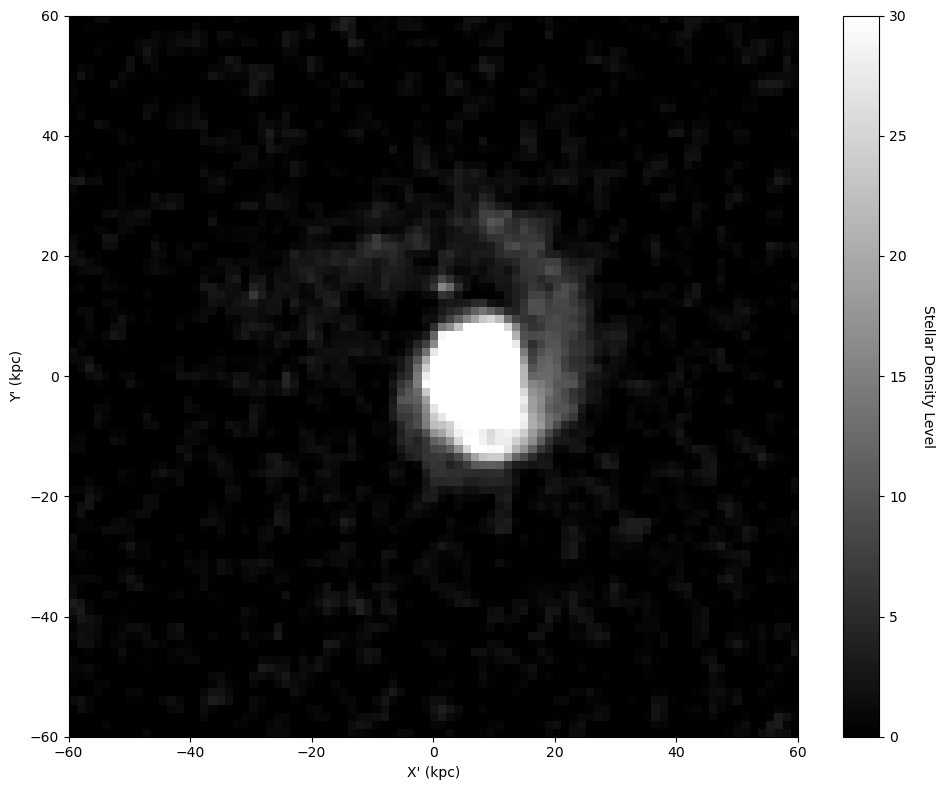

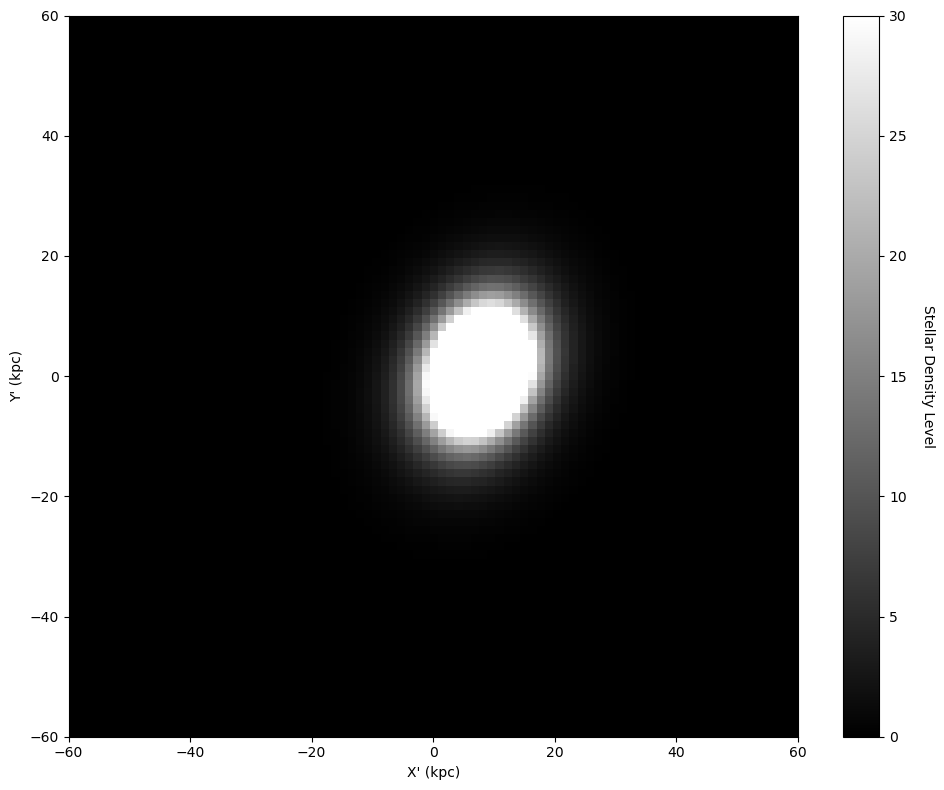

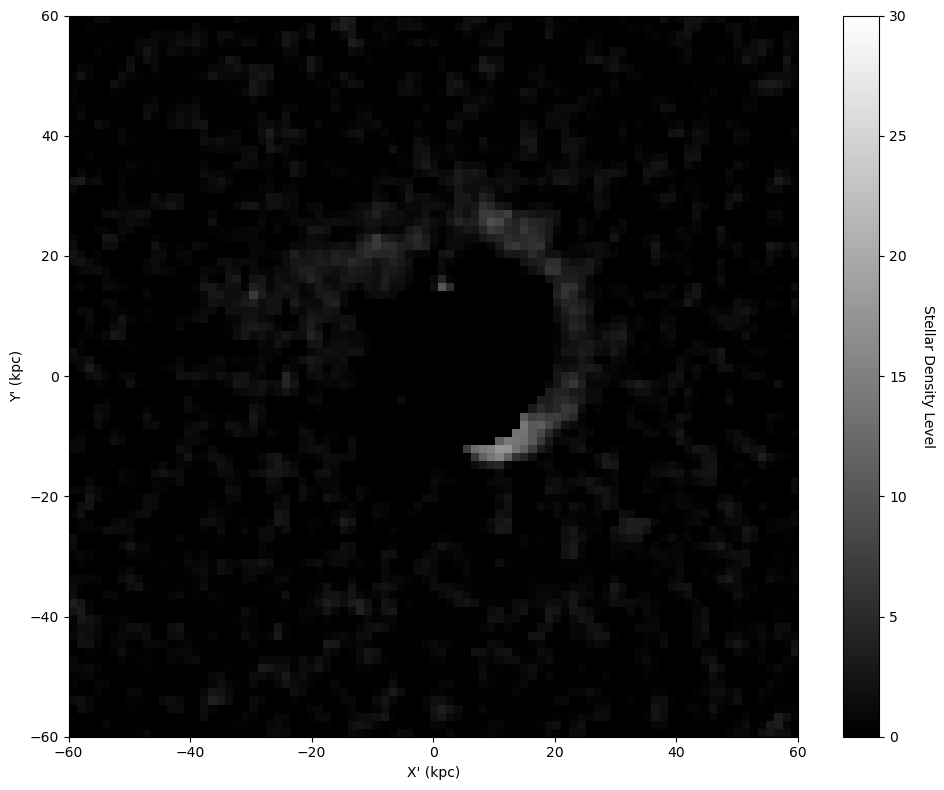

File name: mf_storm_2_d=17.0_a=222.5_pix=8000.fits
Fitted Parameters:
A  = 423.7296
h = 4.3145
q = 0.7578
x_offset = 7.2959
y_offset = -0.3599
theta = -4087943.5156
C  = -0.0963


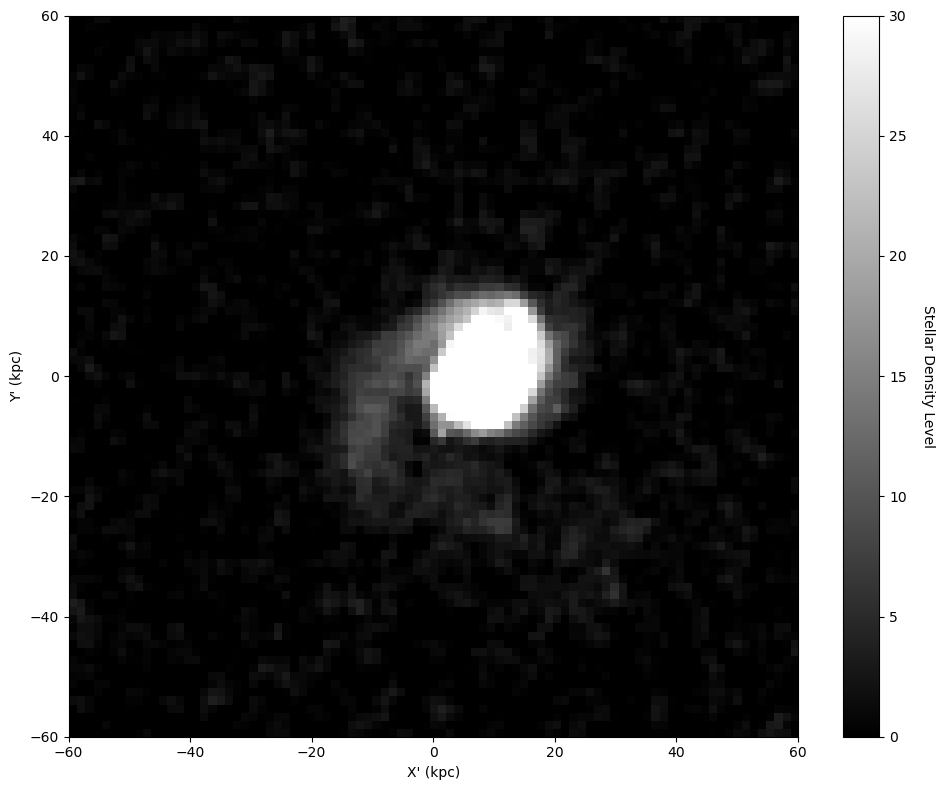

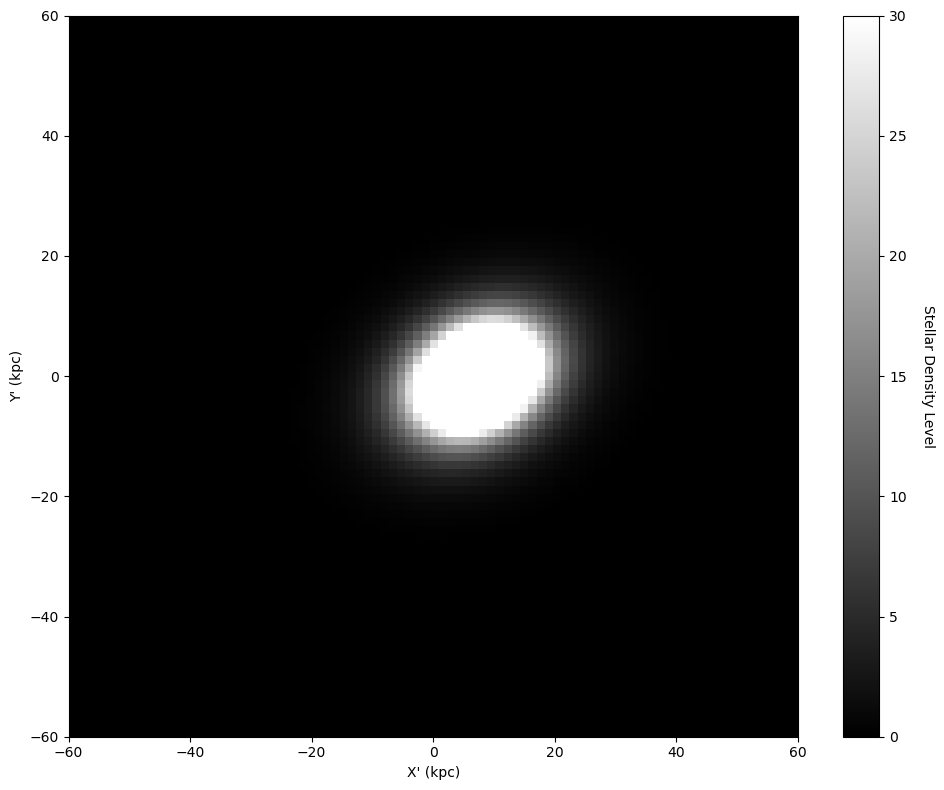

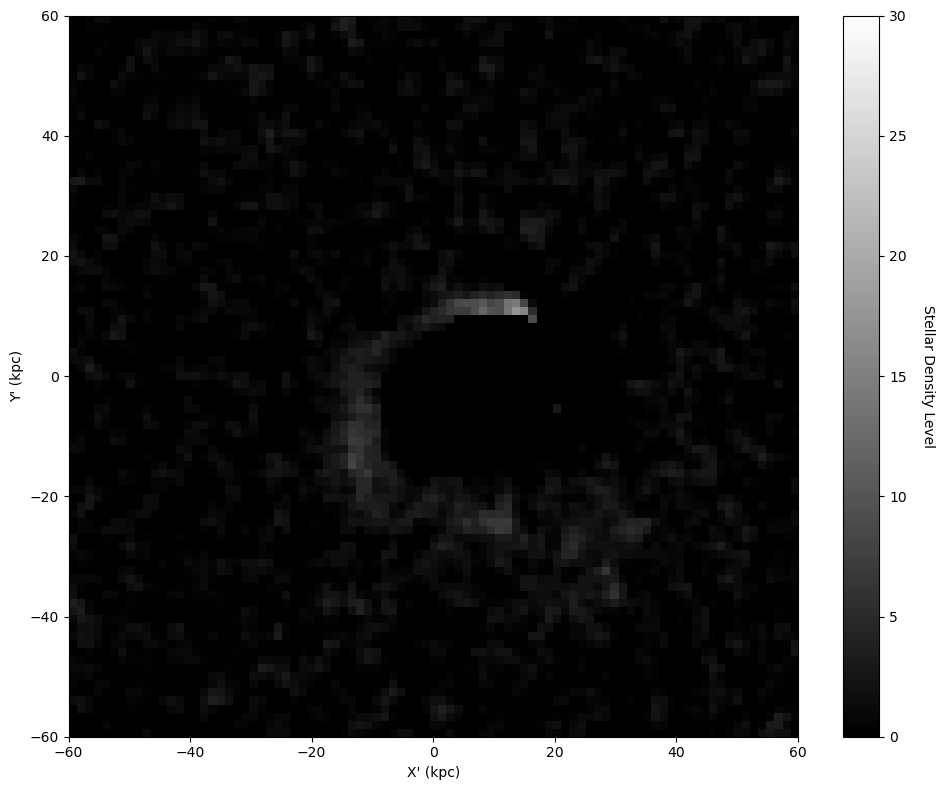

File name: mf_storm_2_d=24.1_a=85.0_pix=8000.fits
Fitted Parameters:
A  = 501.0295
h = 4.0408
q = 0.6887
x_offset = 8.6263
y_offset = -0.2102
theta = 7054741.2354
C  = 0.0305


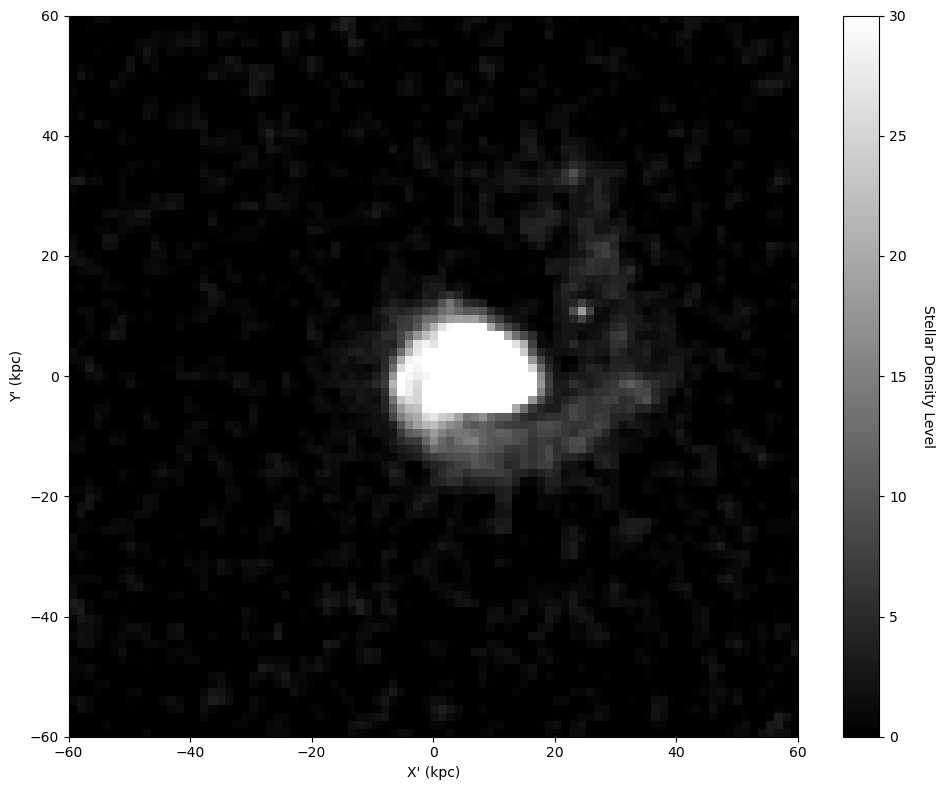

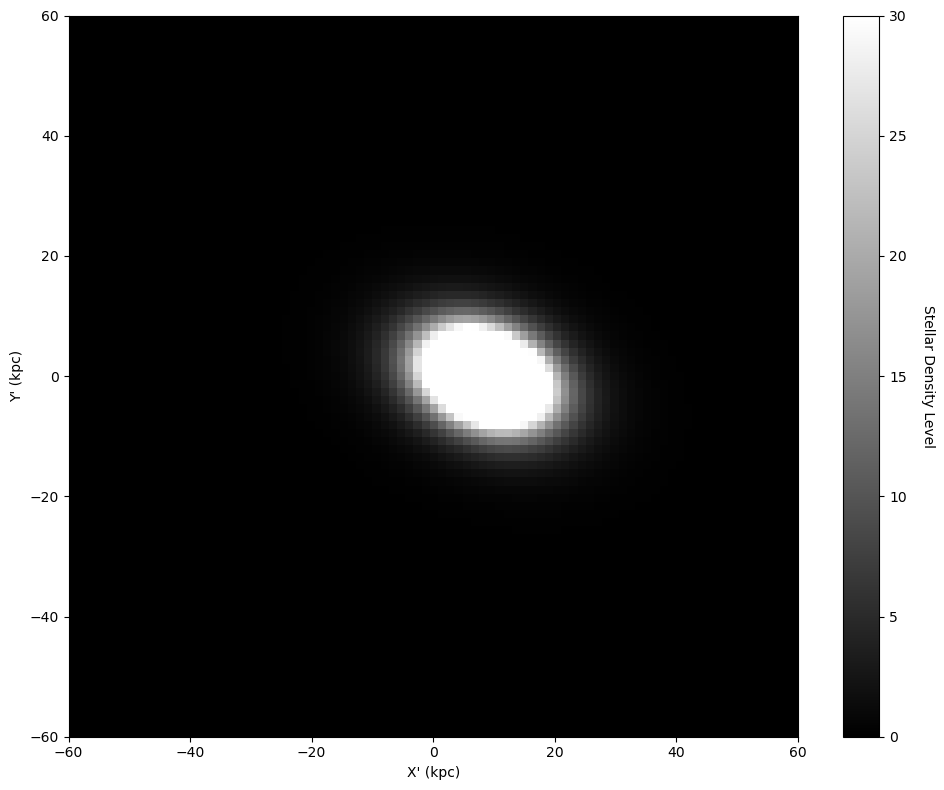

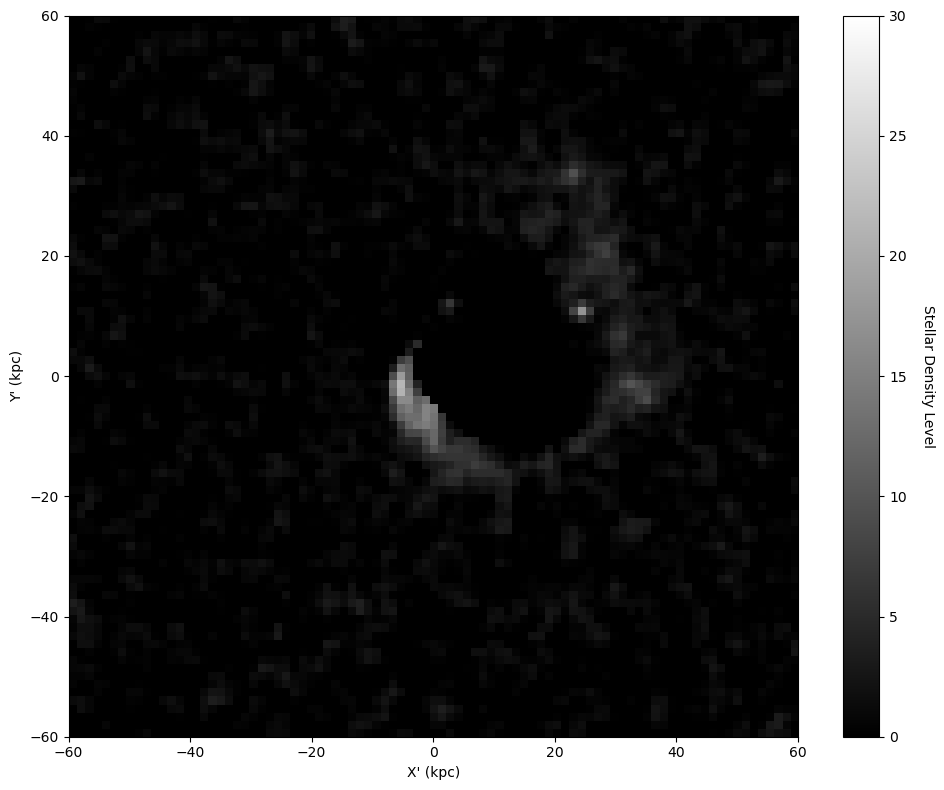

File name: mf_storm_2_d=29.6_a=307.5_pix=8000.fits
Fitted Parameters:
A  = 469.3383
h = 3.2680
q = 1.1776
x_offset = 6.9349
y_offset = 0.3616
theta = 7279039.2073
C  = -0.0754


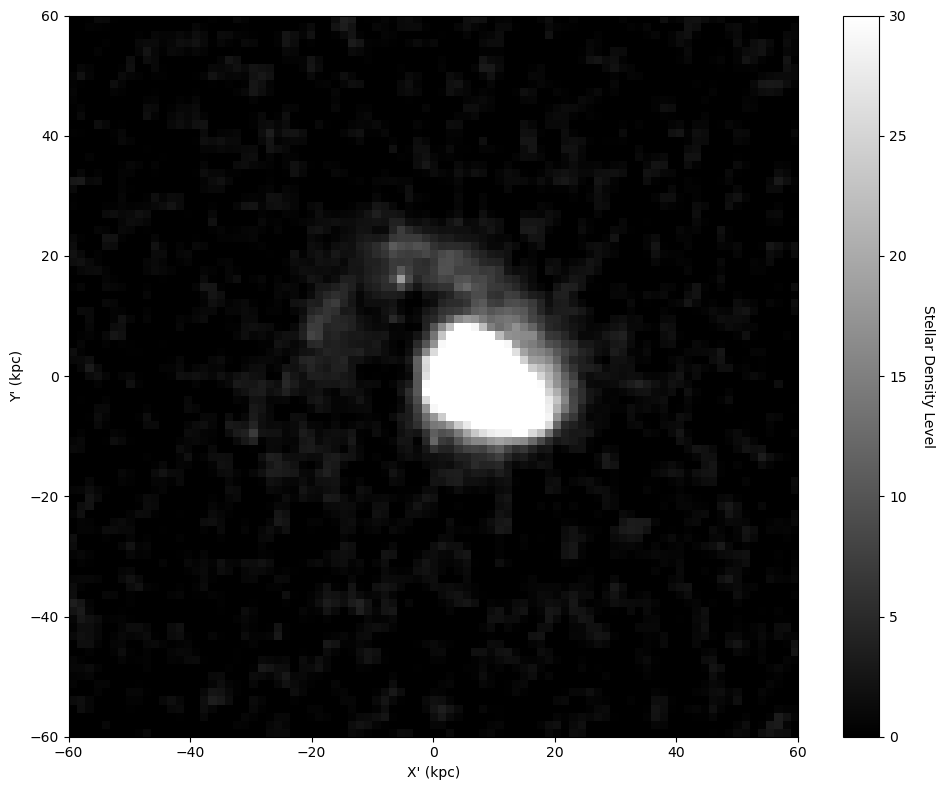

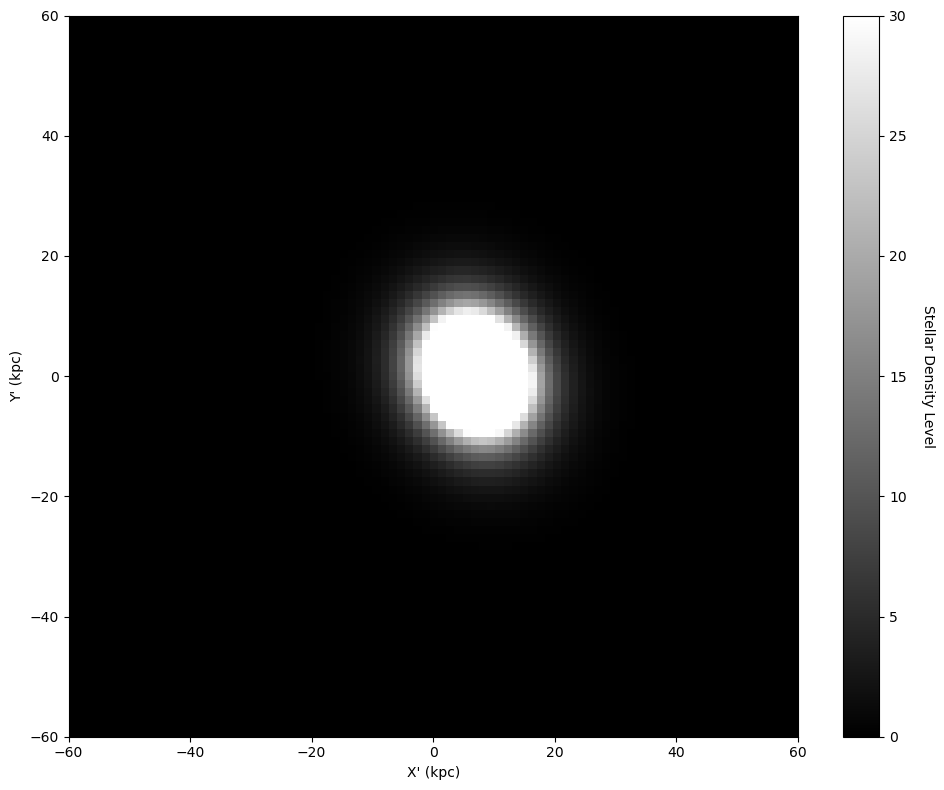

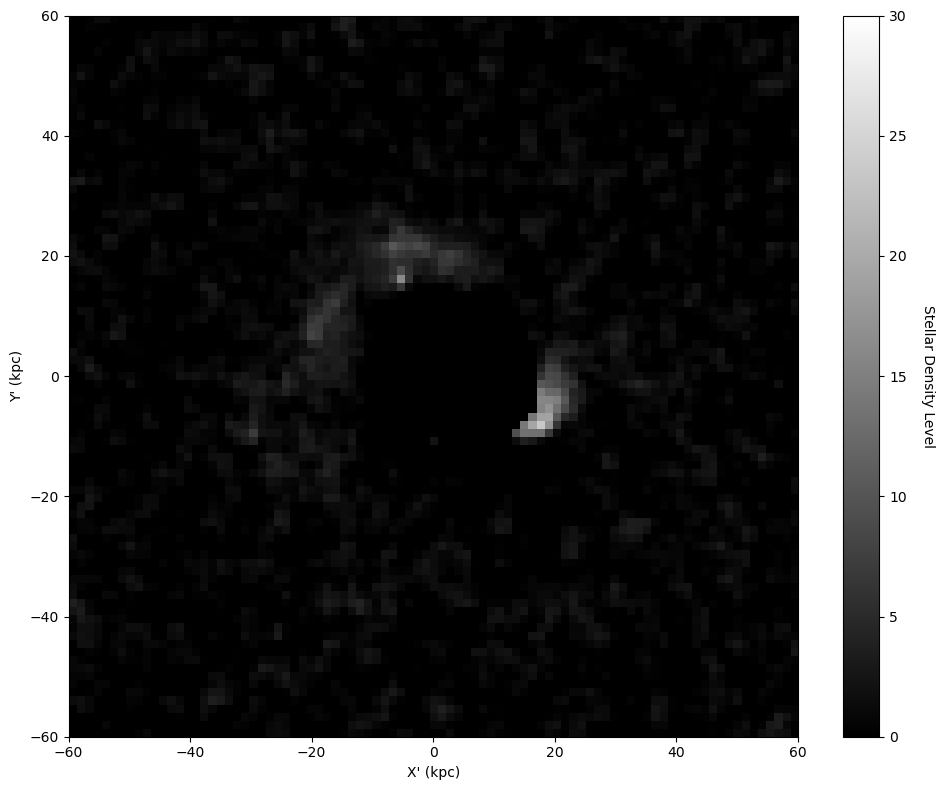

File name: mf_storm_2_d=34.3_a=170.0_pix=8000.fits
Fitted Parameters:
A  = 487.8708
h = 3.2881
q = 1.1290
x_offset = 7.0814
y_offset = -0.4964
theta = -990110.7749
C  = -0.1018


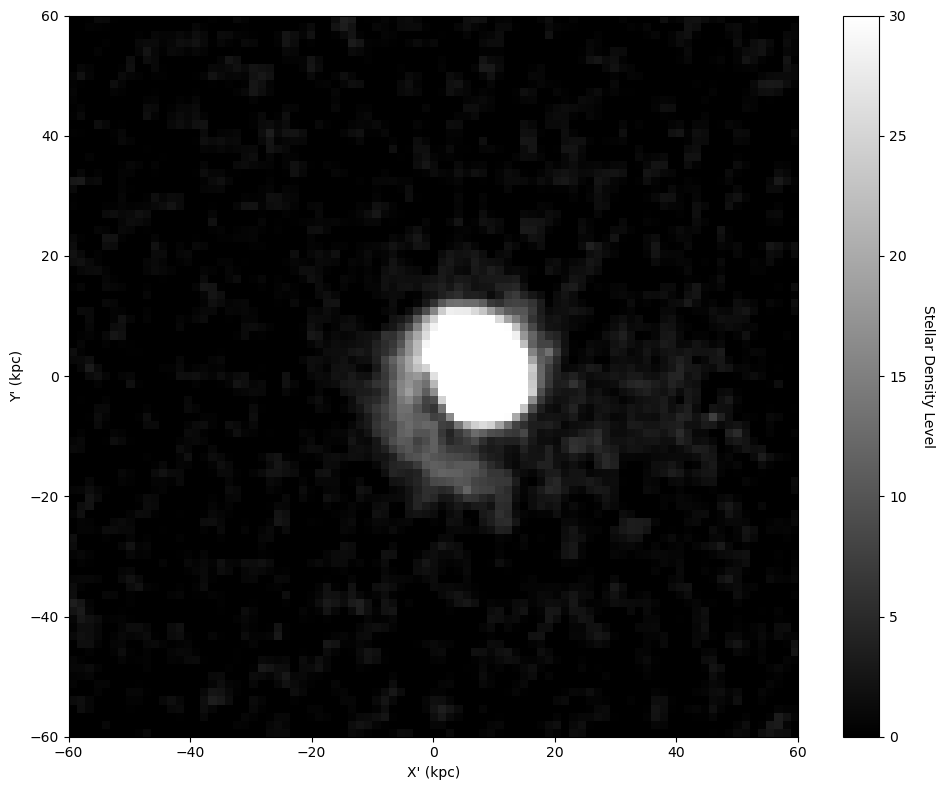

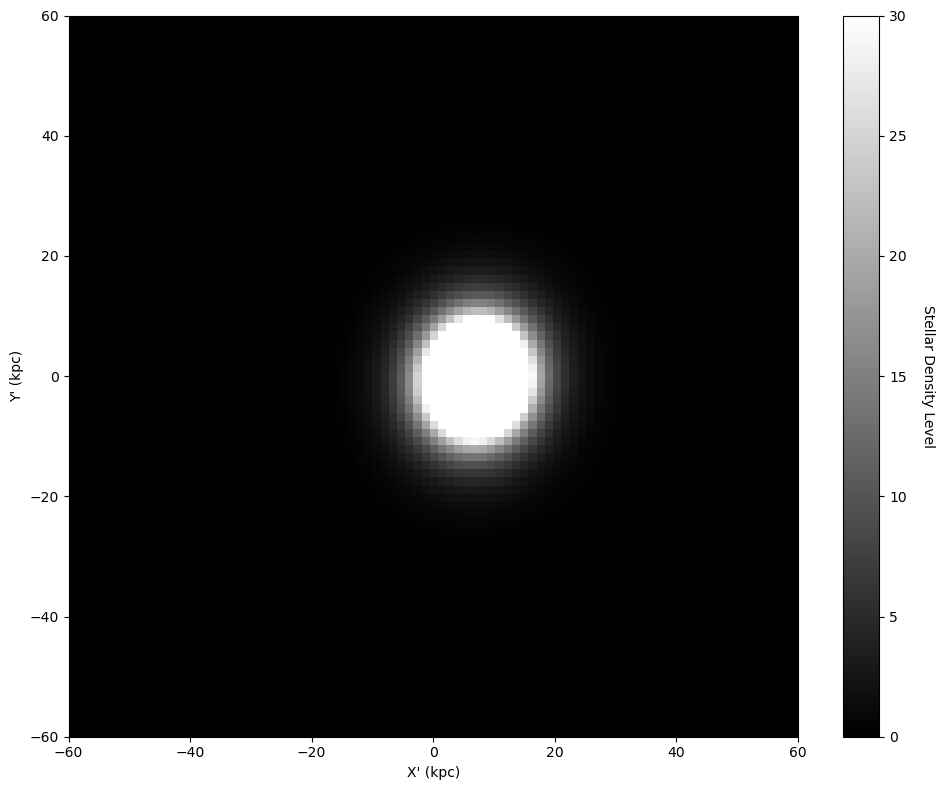

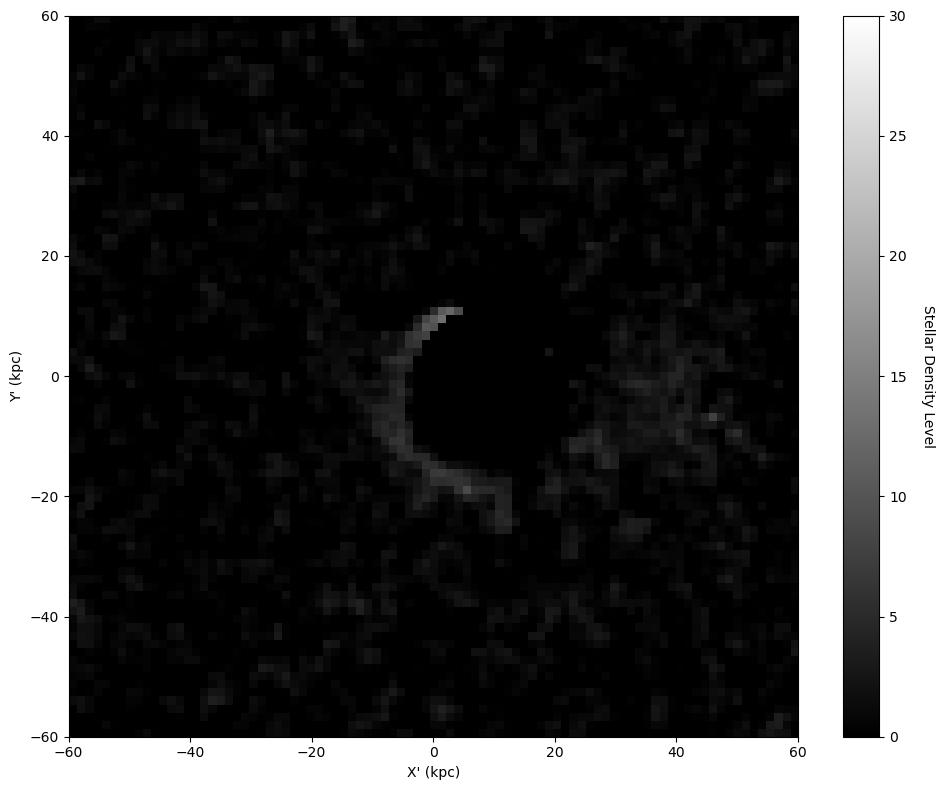

File name: mf_storm_2_d=38.5_a=32.5_pix=8000.fits
Fitted Parameters:
A  = 609.4860
h = 3.9469
q = 0.6015
x_offset = 7.3398
y_offset = 0.7067
theta = -13071525.6762
C  = 0.0659


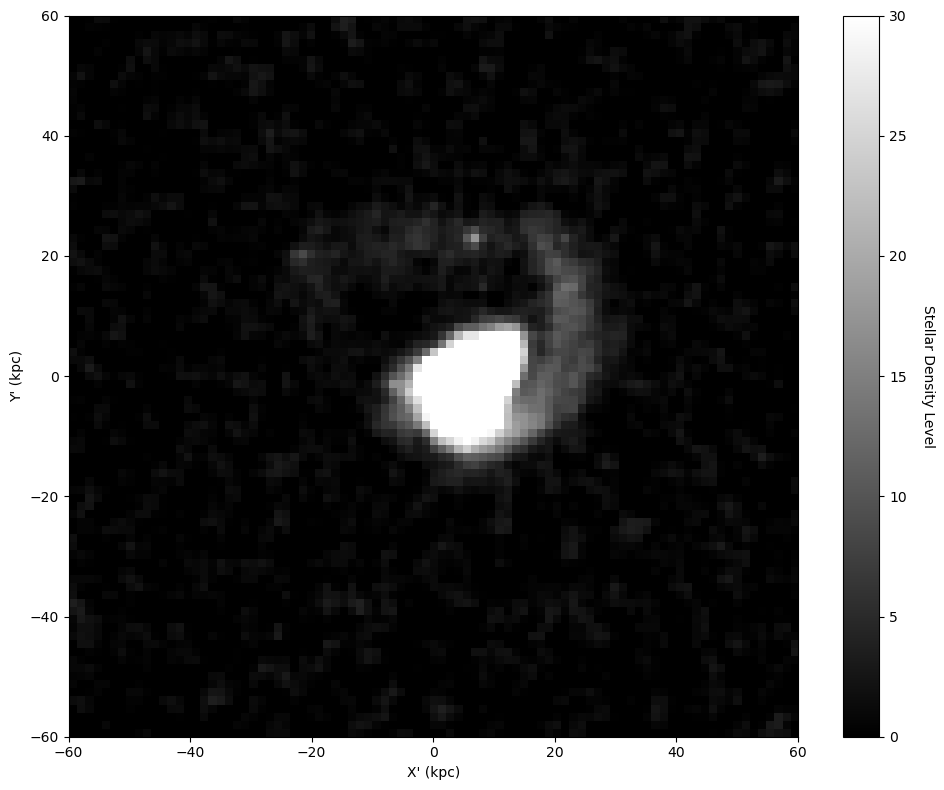

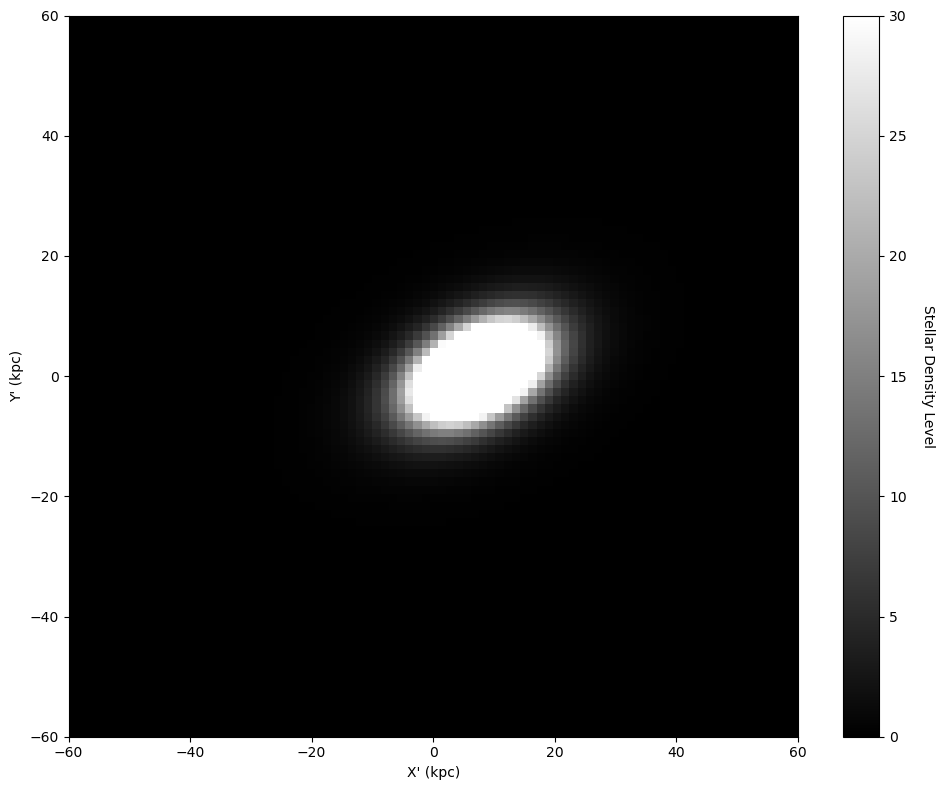

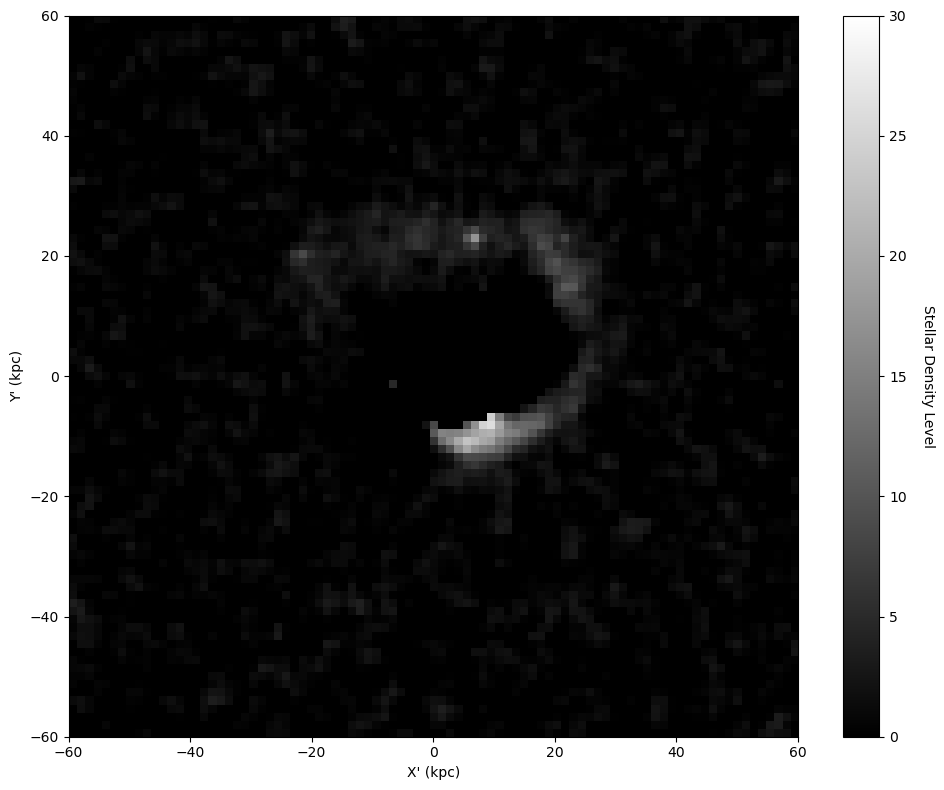

File name: mf_storm_2_d=42.3_a=255.0_pix=8000.fits
Fitted Parameters:
A  = 490.1691
h = 4.4269
q = 0.6542
x_offset = 7.1628
y_offset = -0.2405
theta = 1540621.2659
C  = -0.1310


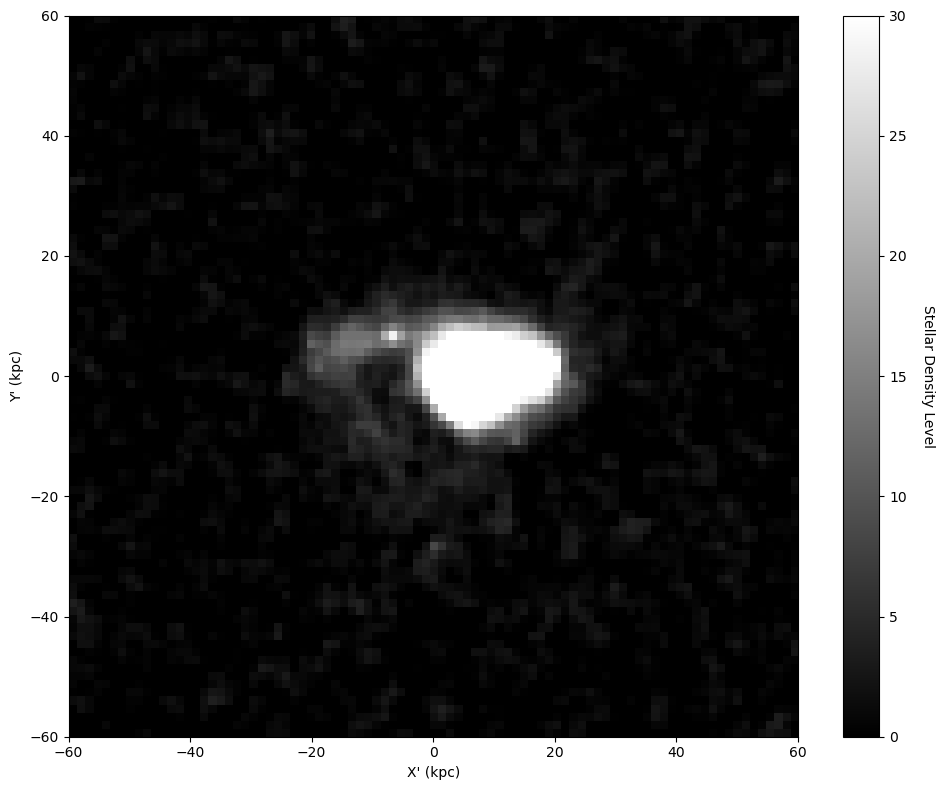

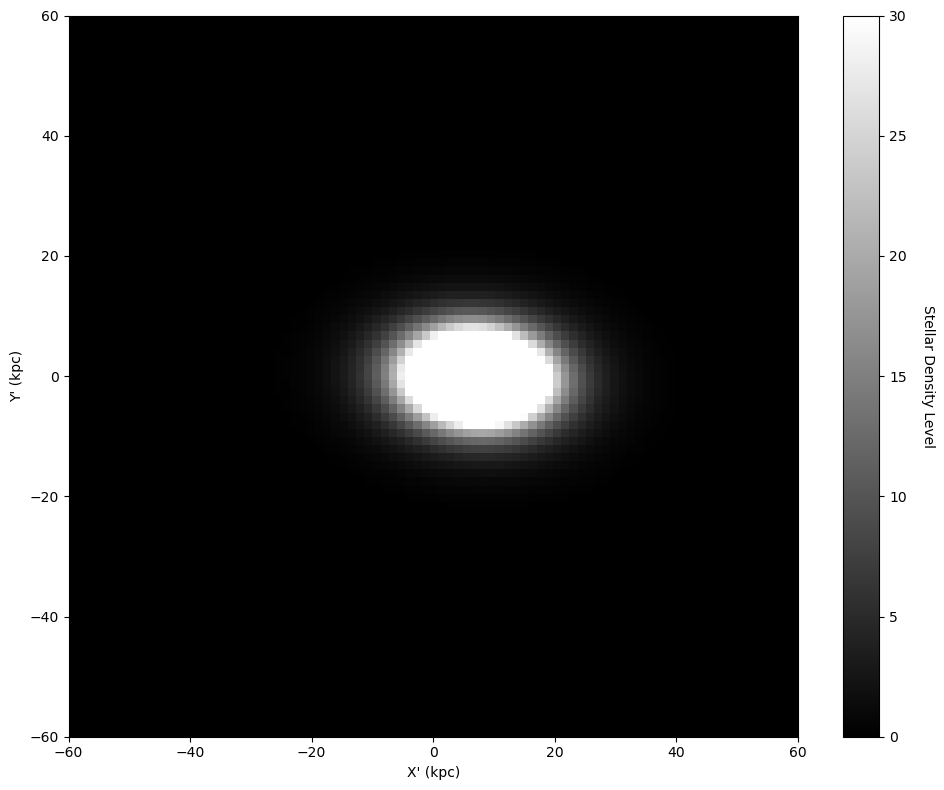

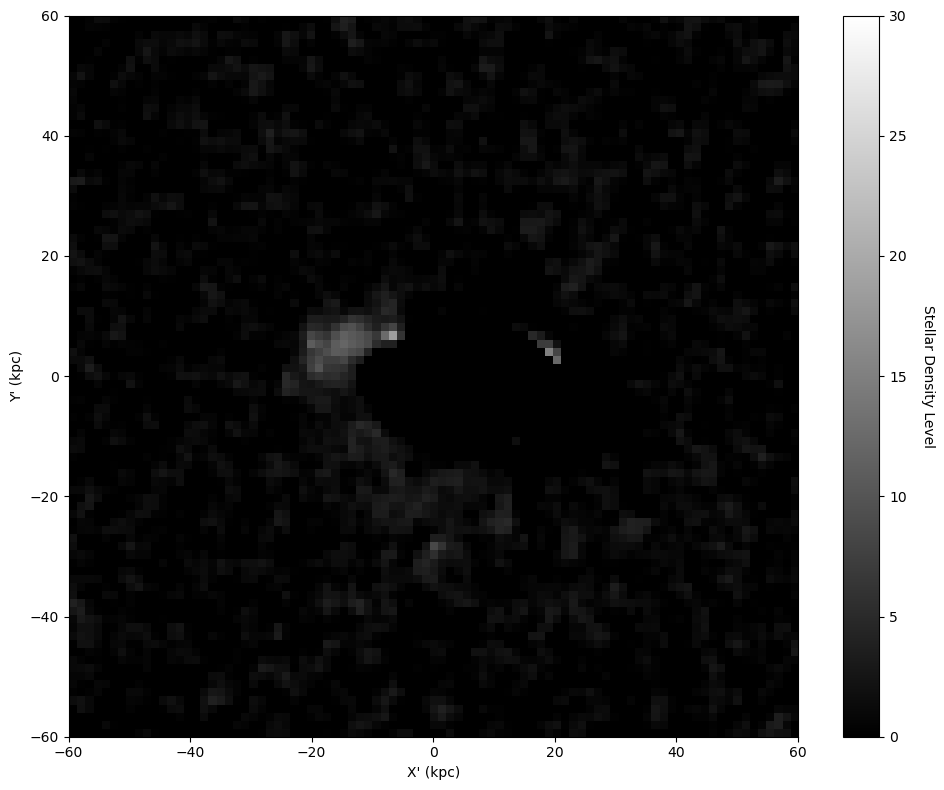

File name: mf_storm_2_d=45.9_a=117.4_pix=8000.fits
Fitted Parameters:
A  = 645.7509
h = 3.7143
q = 0.6312
x_offset = 7.4412
y_offset = -0.4995
theta = 7121562.6381
C  = 0.0701


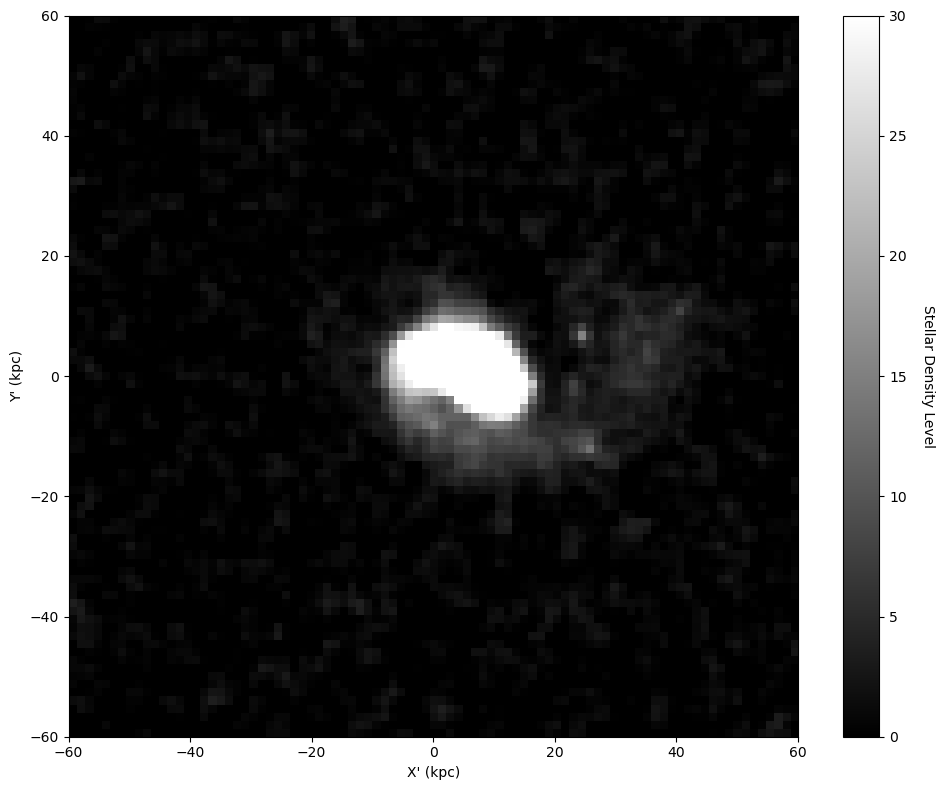

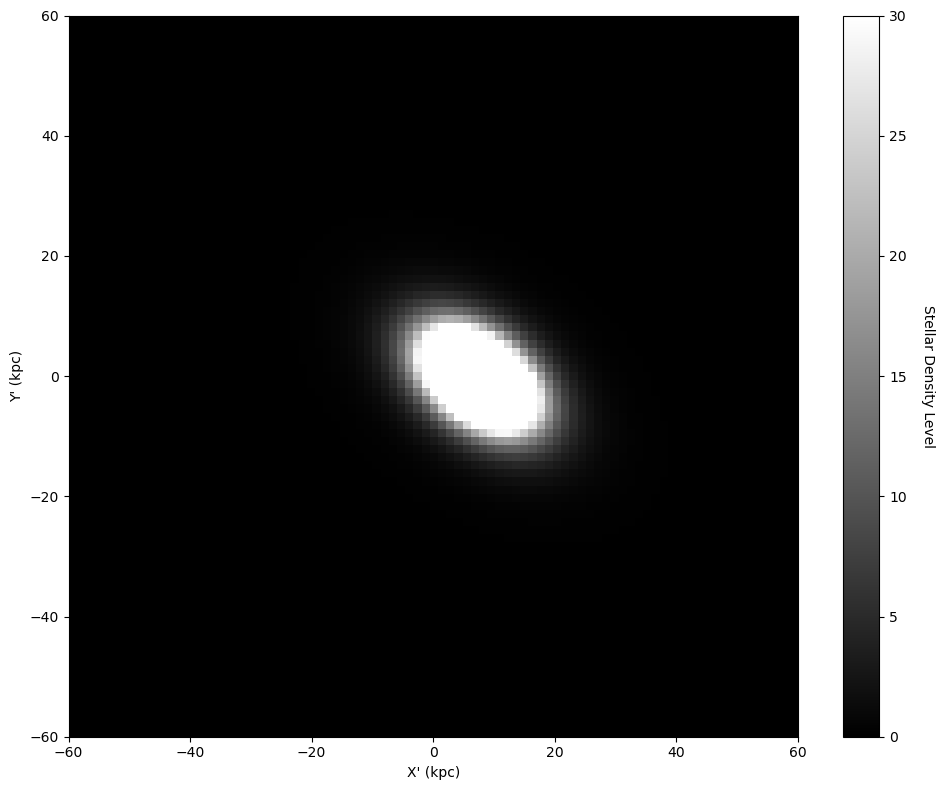

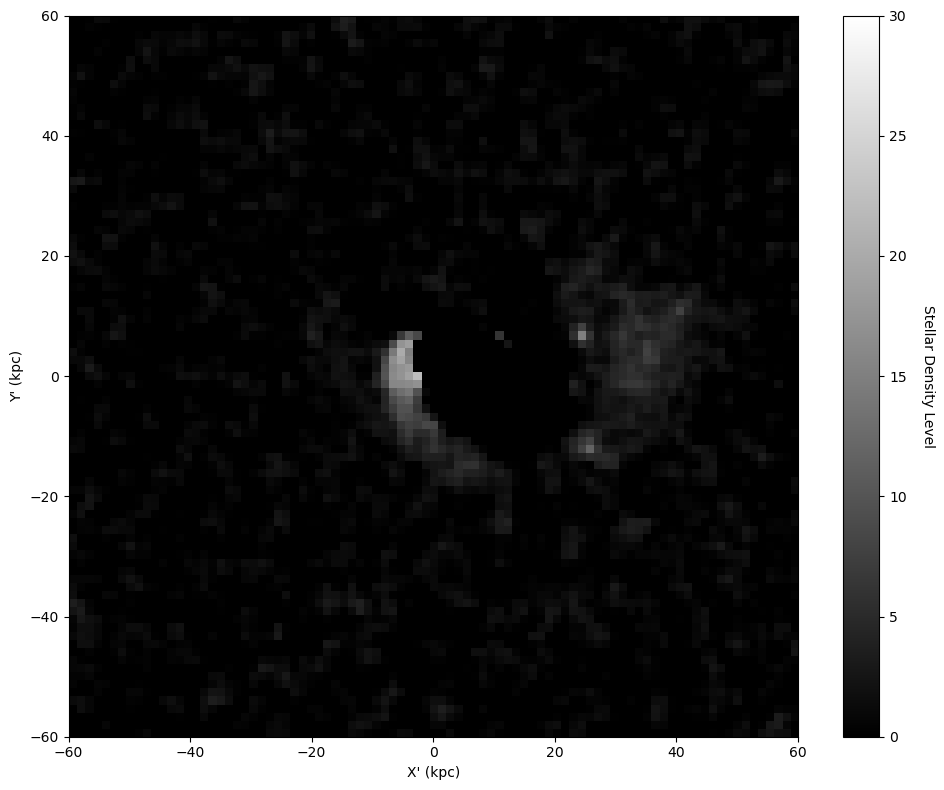

File name: mf_storm_2_d=49.3_a=339.9_pix=8000.fits
Fitted Parameters:
A  = 668.6272
h = 2.6343
q = 1.2329
x_offset = 6.0847
y_offset = 0.1946
theta = -4370151.3329
C  = 0.0347


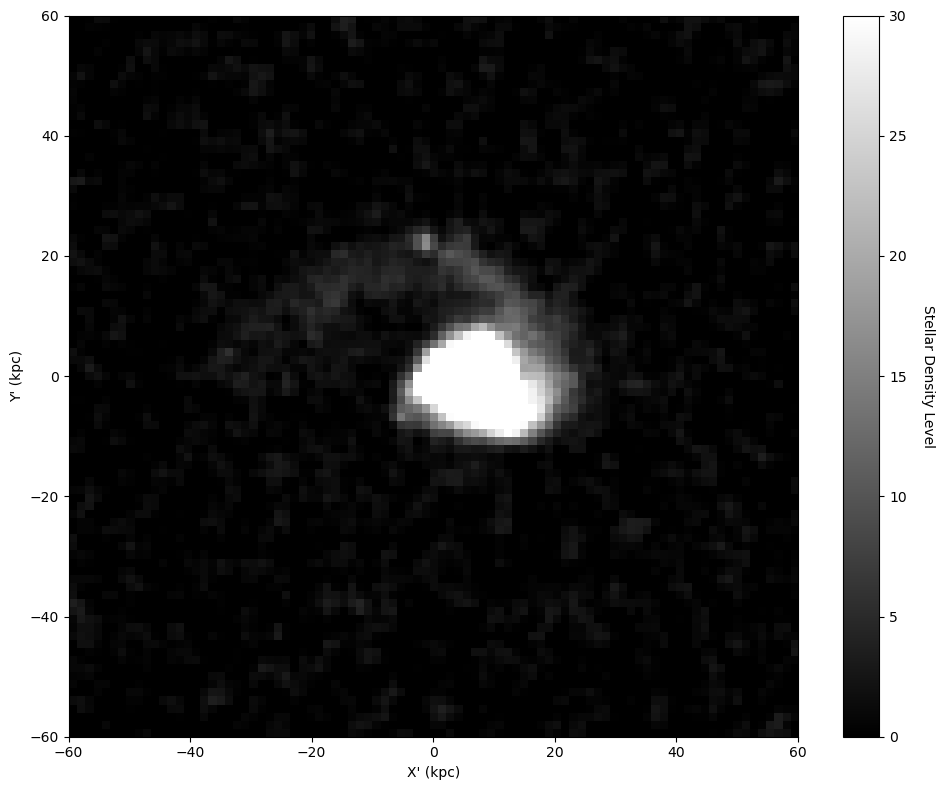

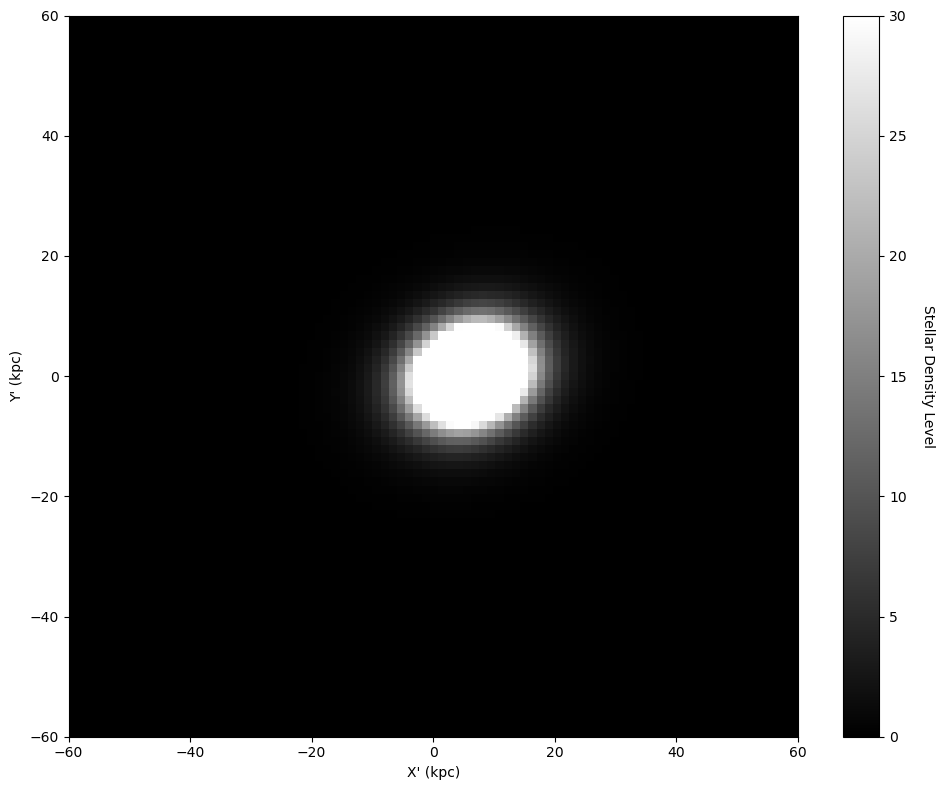

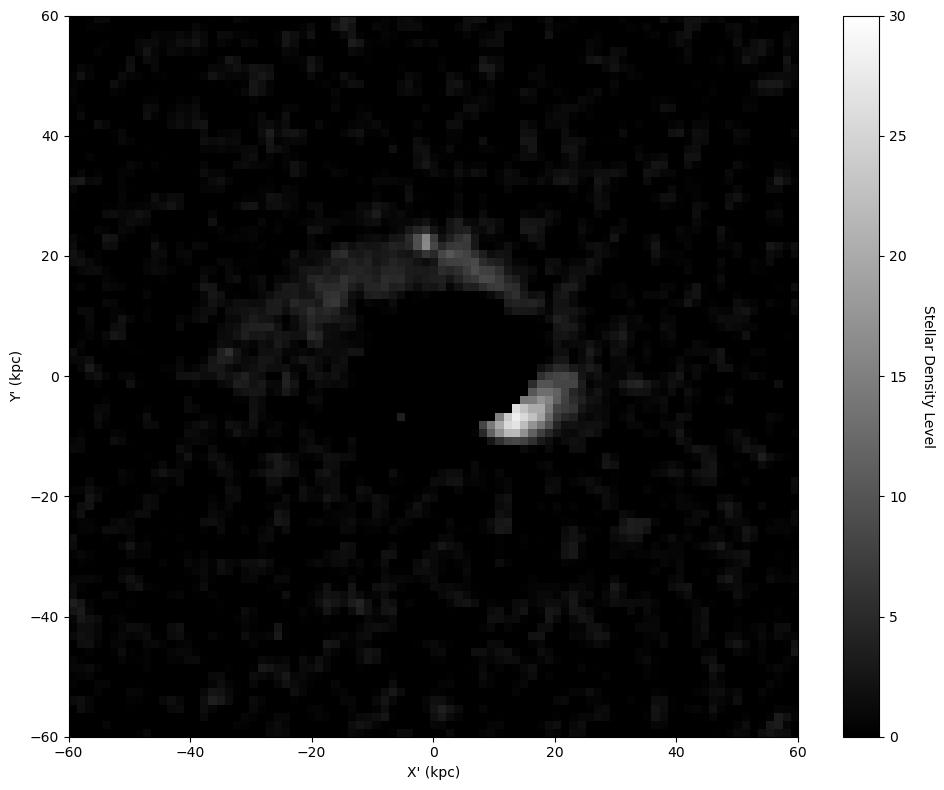

File name: mf_storm_2_d=52.5_a=202.4_pix=8000.fits
Fitted Parameters:
A  = 566.5188
h = 3.9731
q = 0.7178
x_offset = 6.2648
y_offset = 0.1837
theta = -8959275.2295
C  = -0.1945


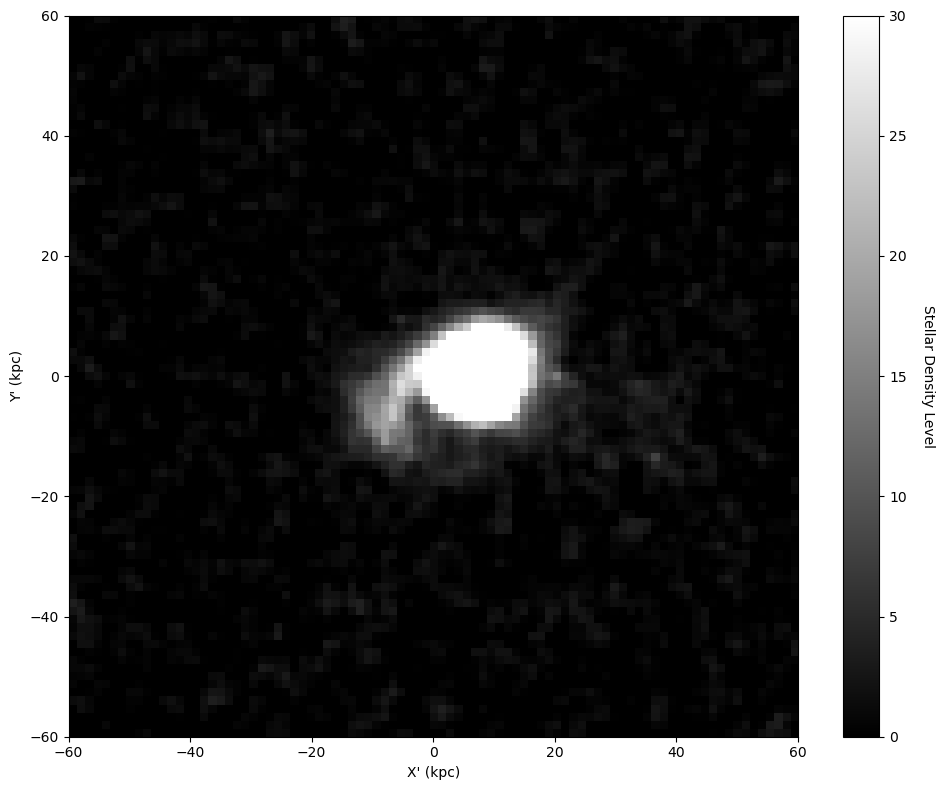

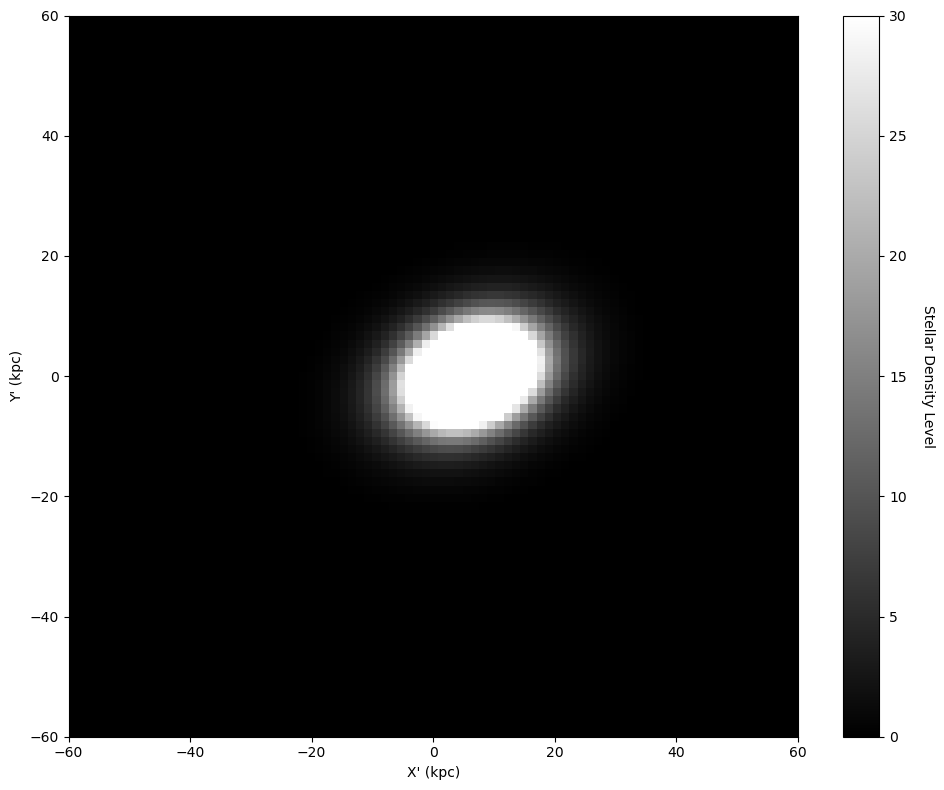

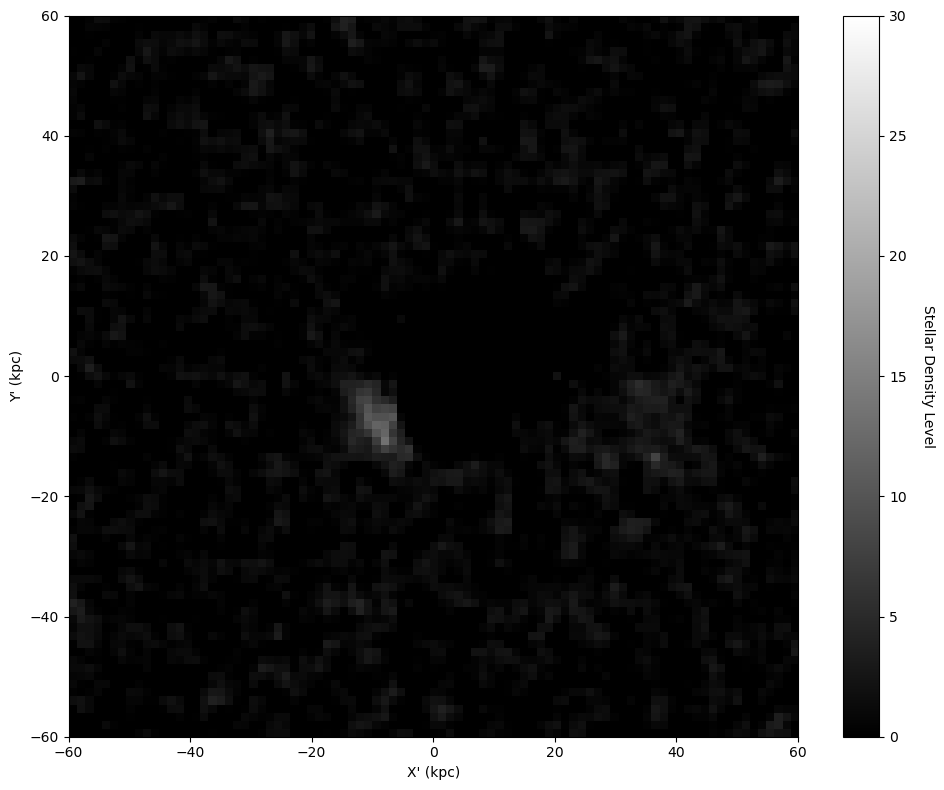

File name: mf_storm_2_d=55.6_a=64.9_pix=8000.fits
Fitted Parameters:
A  = 801.7228
h = 3.9083
q = 0.4626
x_offset = 7.3159
y_offset = 0.3855
theta = -3352729.6592
C  = 0.1277


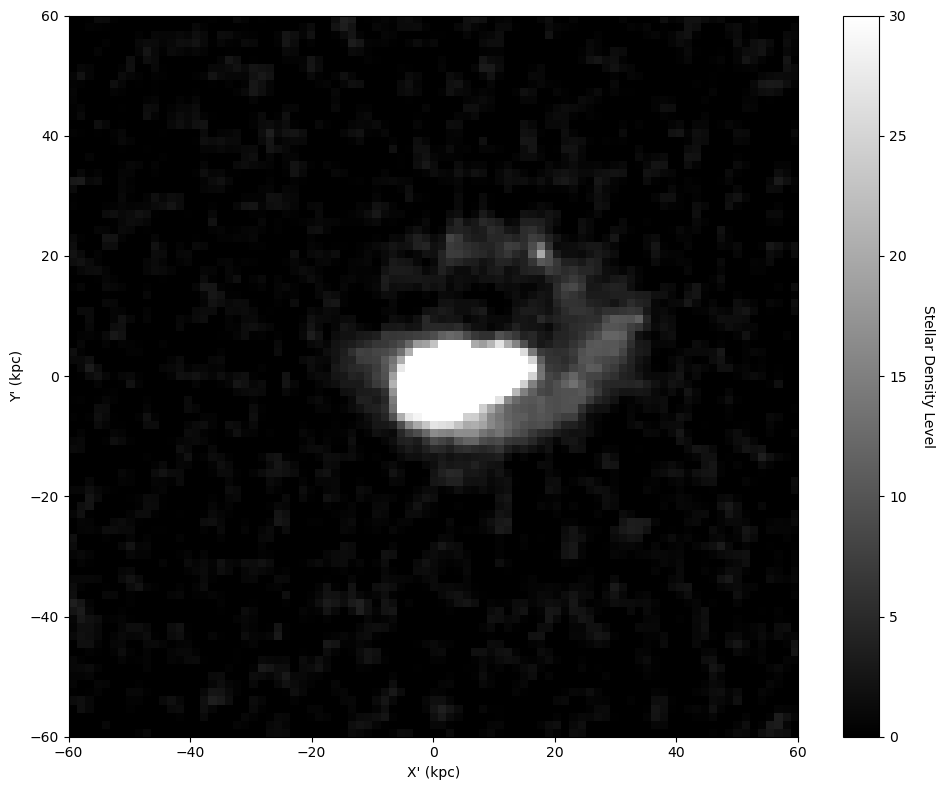

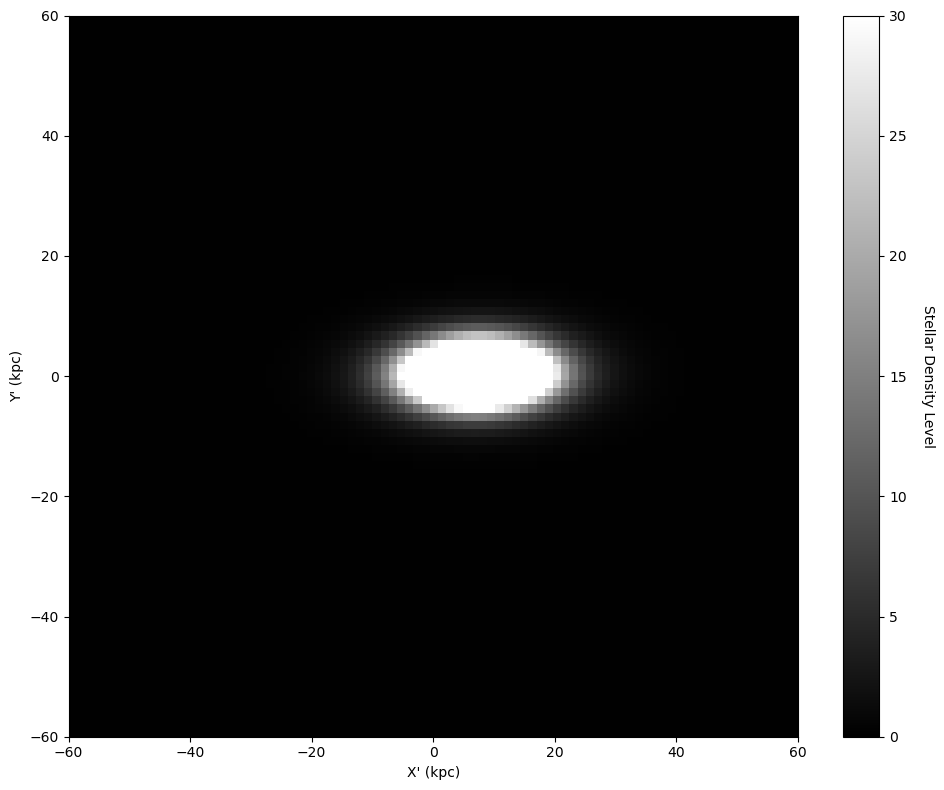

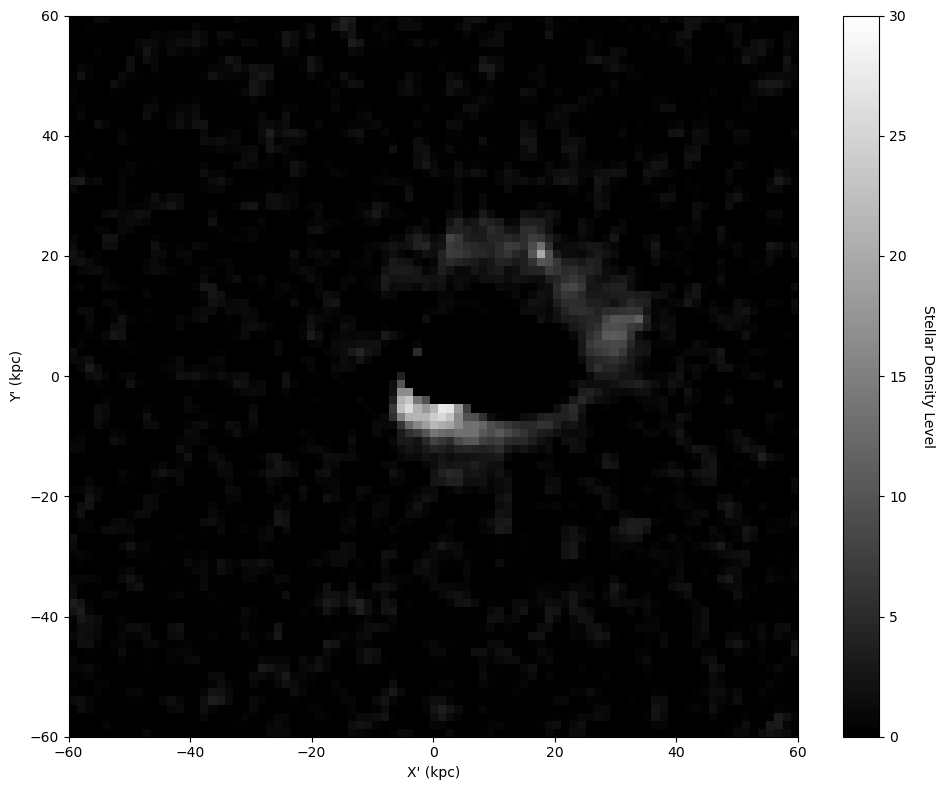

File name: mf_storm_2_d=58.6_a=287.4_pix=8000.fits
Fitted Parameters:
A  = 657.6466
h = 3.9376
q = 0.5985
x_offset = 6.2134
y_offset = -0.0925
theta = 2502812.2435
C  = -0.0599


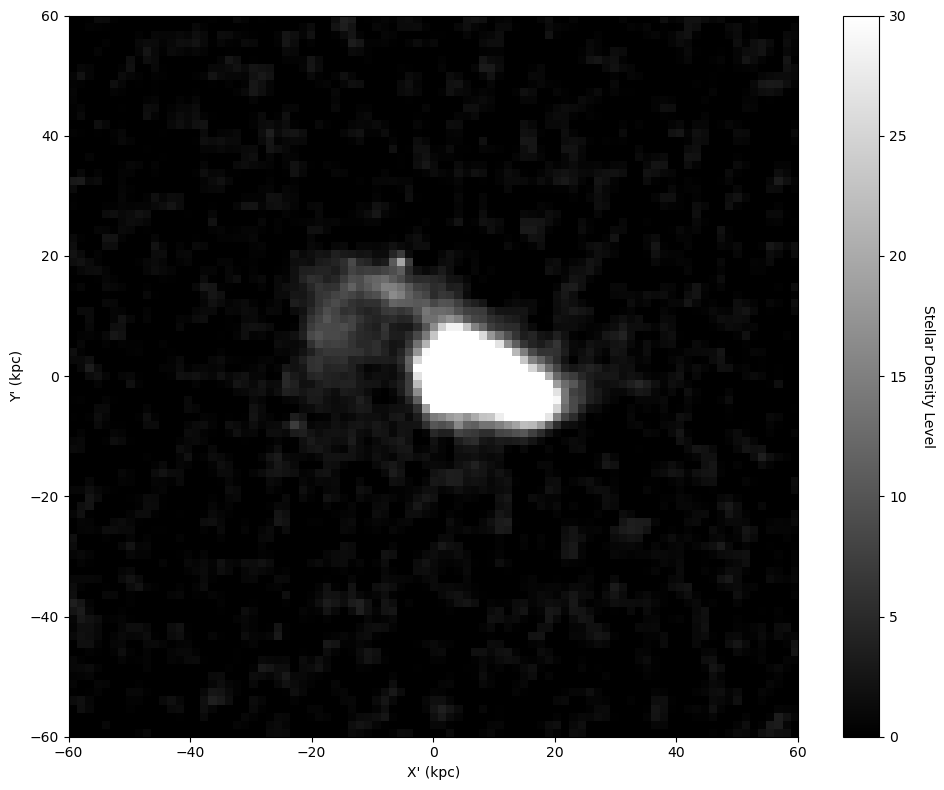

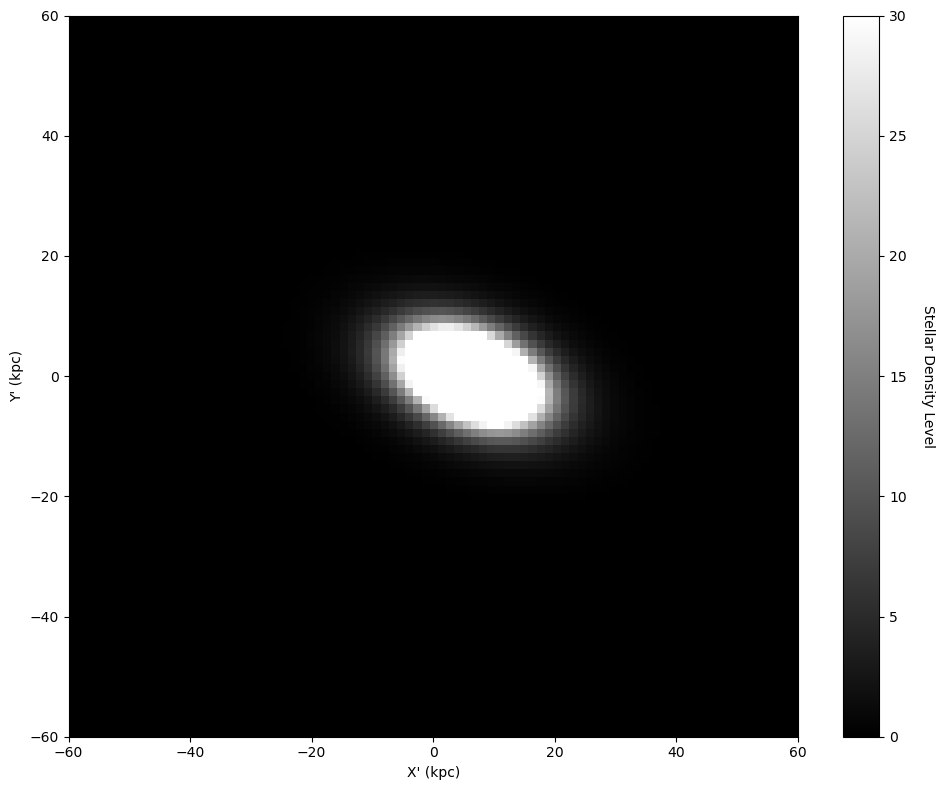

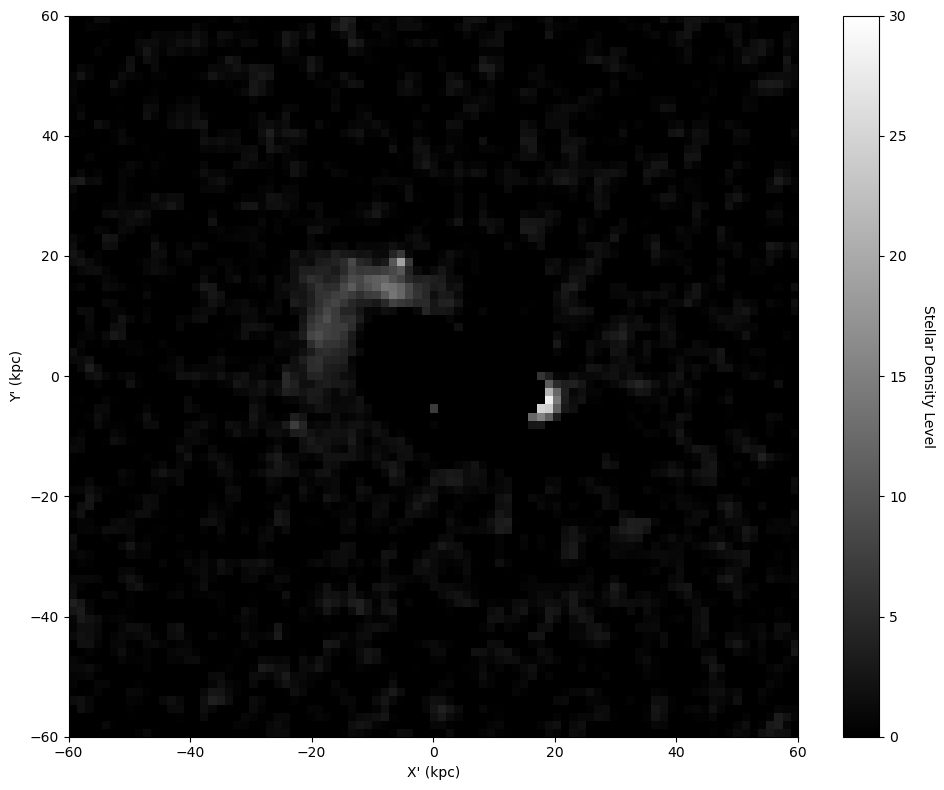

File name: mf_storm_2_d=61.4_a=149.9_pix=8000.fits
Fitted Parameters:
A  = 789.2259
h = 3.3771
q = 0.6677
x_offset = 6.0332
y_offset = -0.0882
theta = -2516739.7716
C  = 0.0016


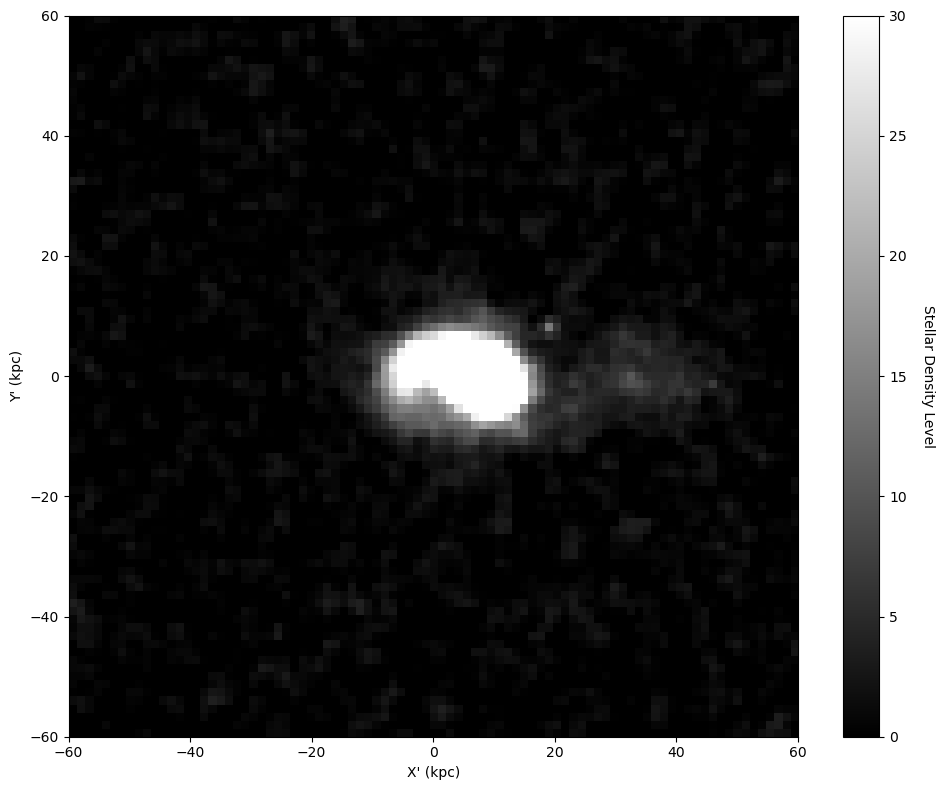

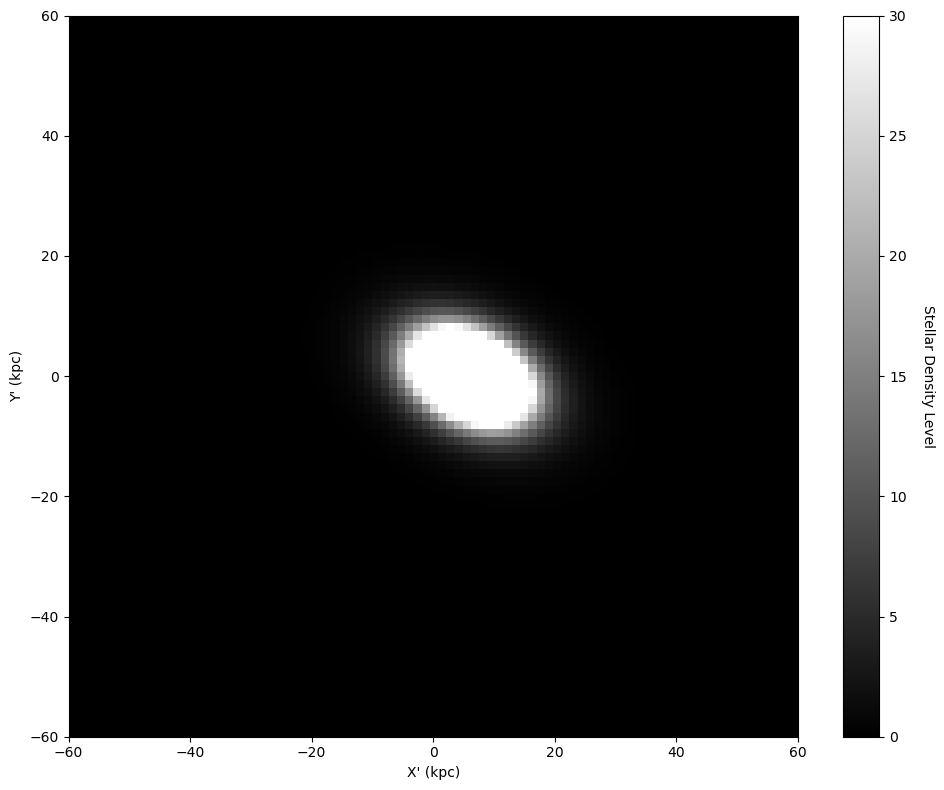

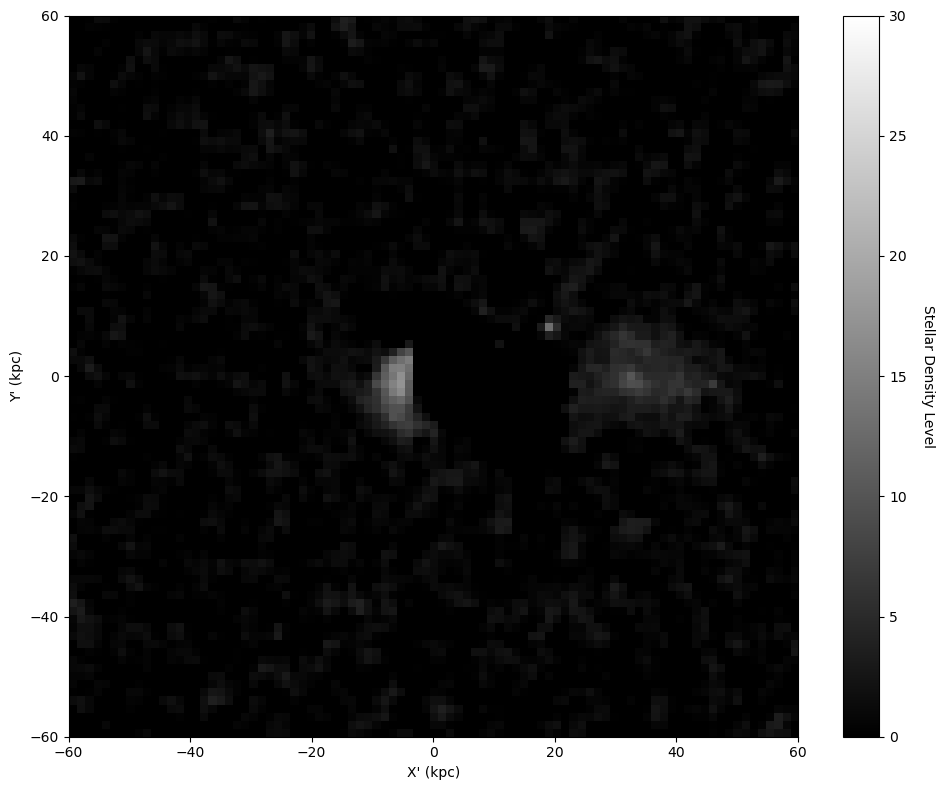

File name: mf_storm_2_d=64.2_a=12.4_pix=8000.fits
Fitted Parameters:
A  = 878.9166
h = 1.8544
q = 1.9744
x_offset = 5.8867
y_offset = 0.2187
theta = -6828903.1896
C  = 0.0155


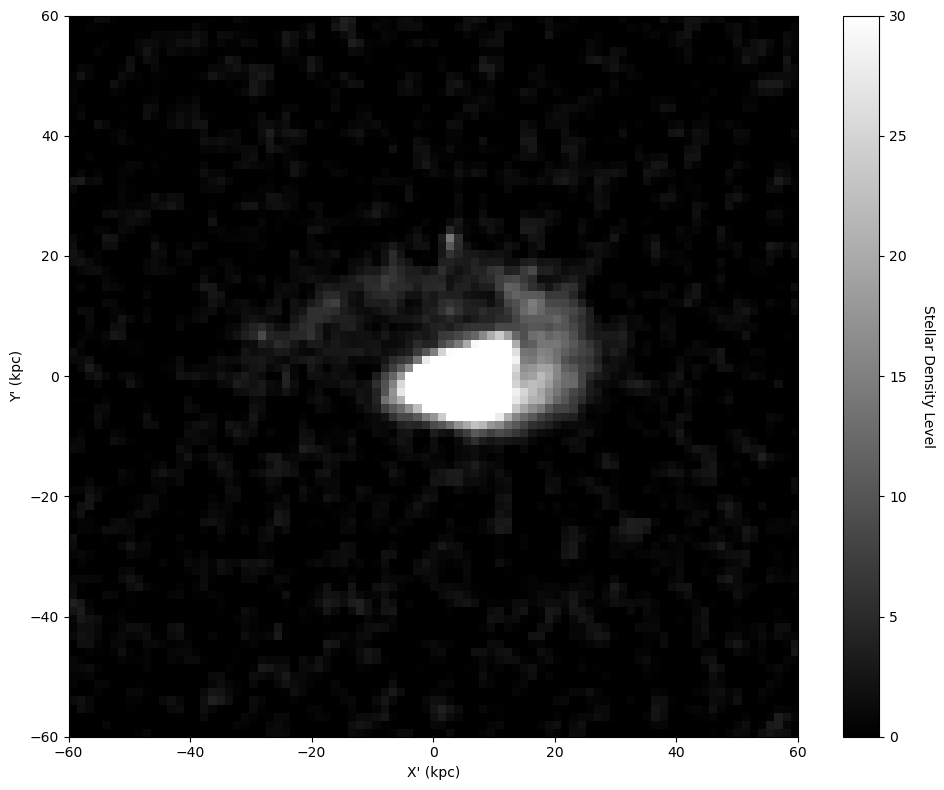

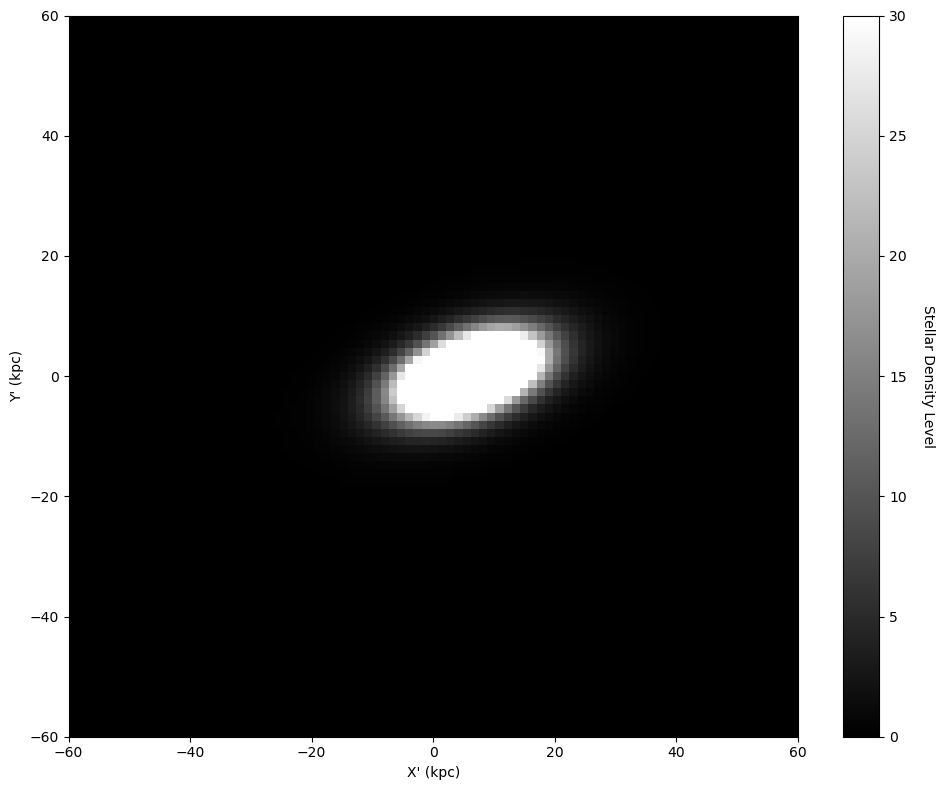

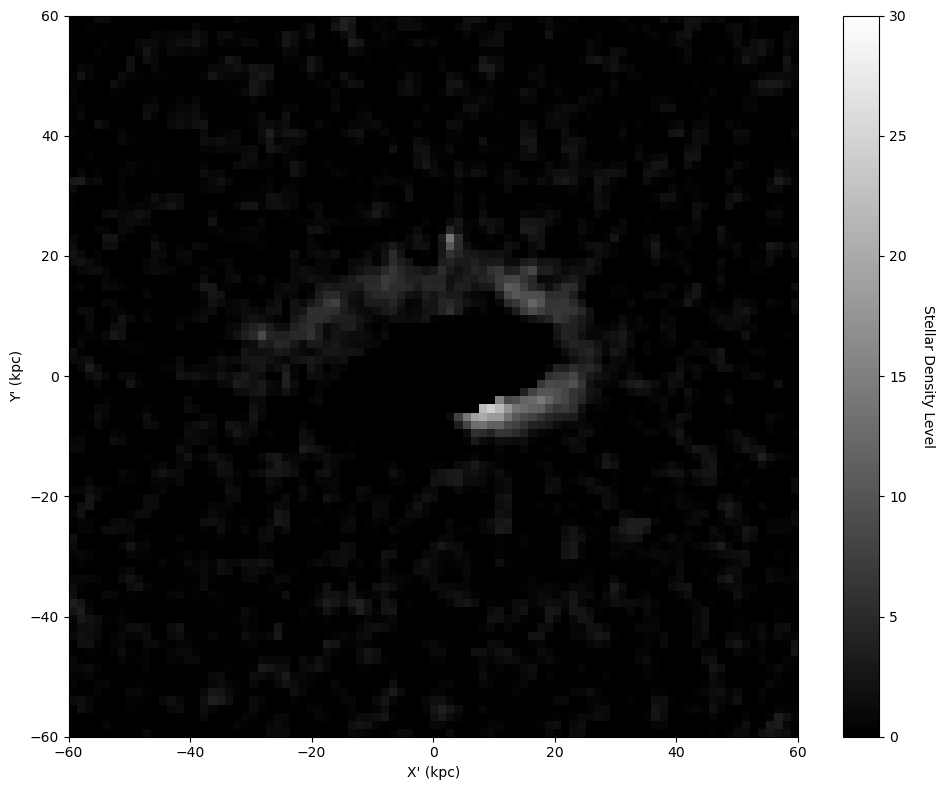

File name: mf_storm_2_d=67.0_a=234.9_pix=8000.fits
Fitted Parameters:
A  = 713.4251
h = 2.0844
q = 2.1336
x_offset = 6.5905
y_offset = 0.3498
theta = -2816175.3008
C  = -0.1716


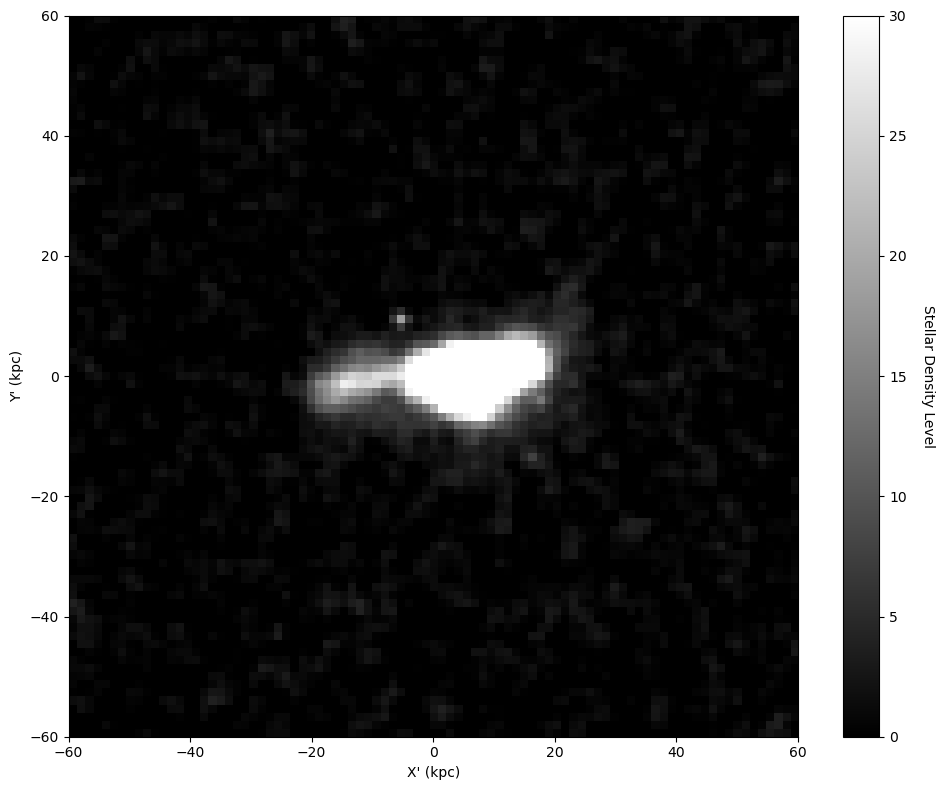

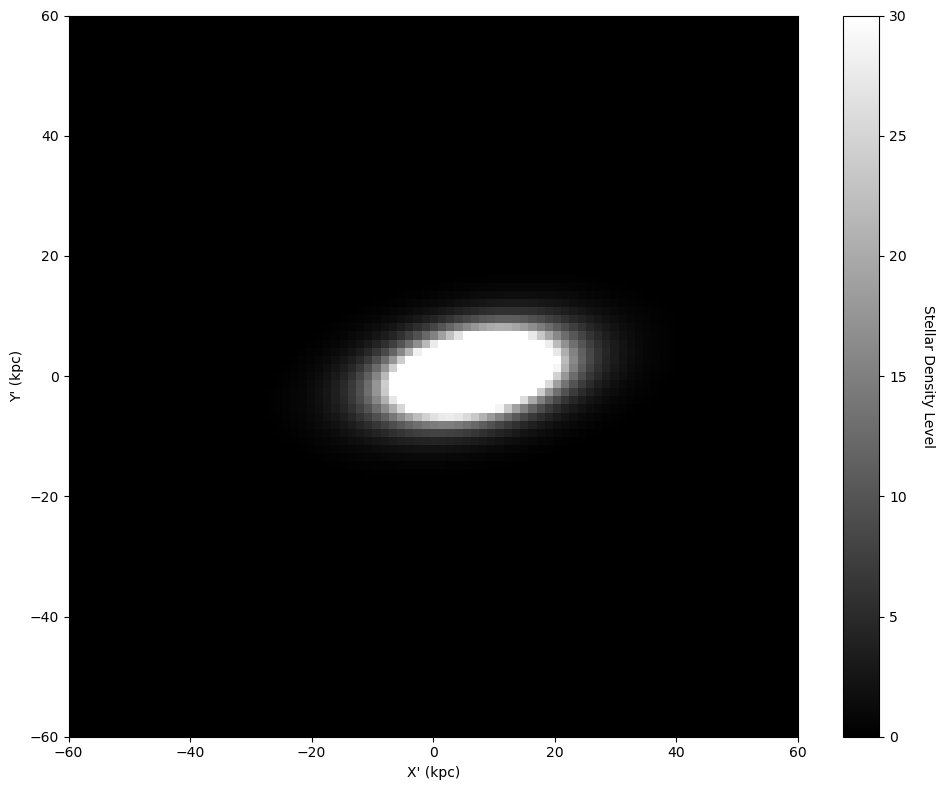

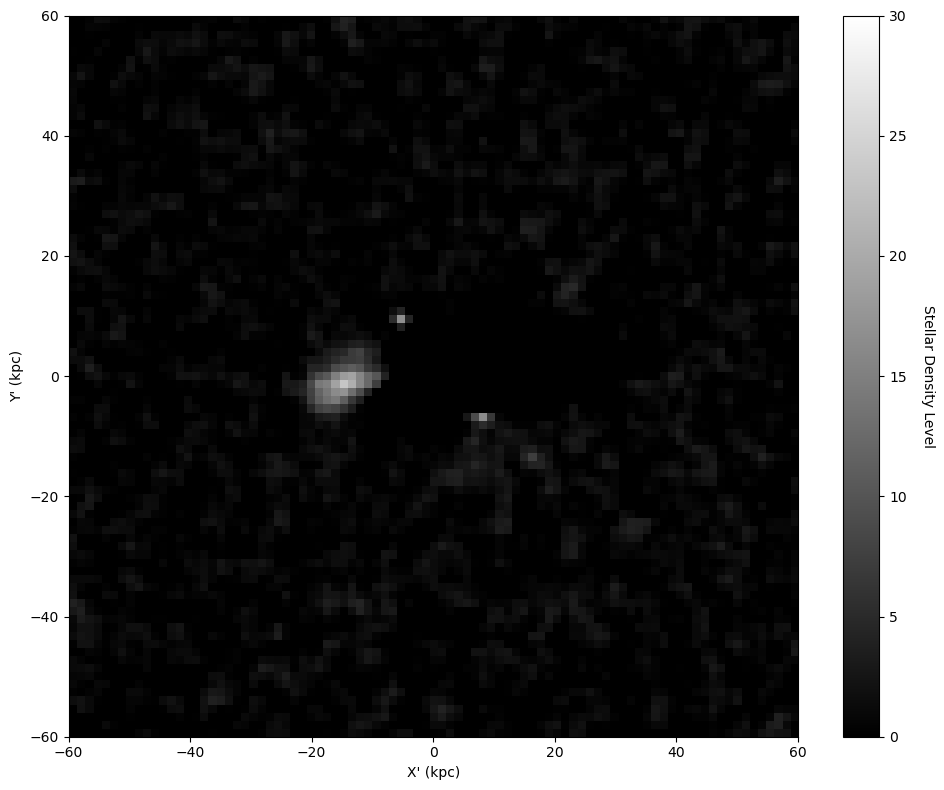

File name: mf_storm_2_d=69.6_a=97.4_pix=8000.fits
Fitted Parameters:
A  = 926.7303
h = 3.9491
q = 0.4116
x_offset = 6.8919
y_offset = -0.2708
theta = -1048208.4803
C  = 0.0470


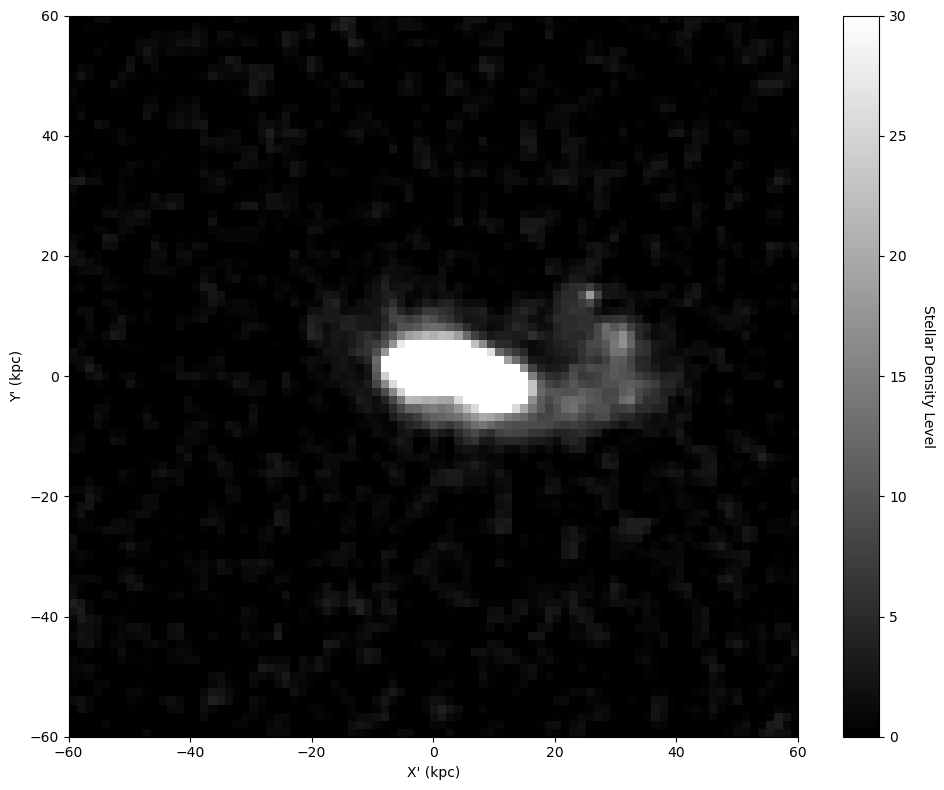

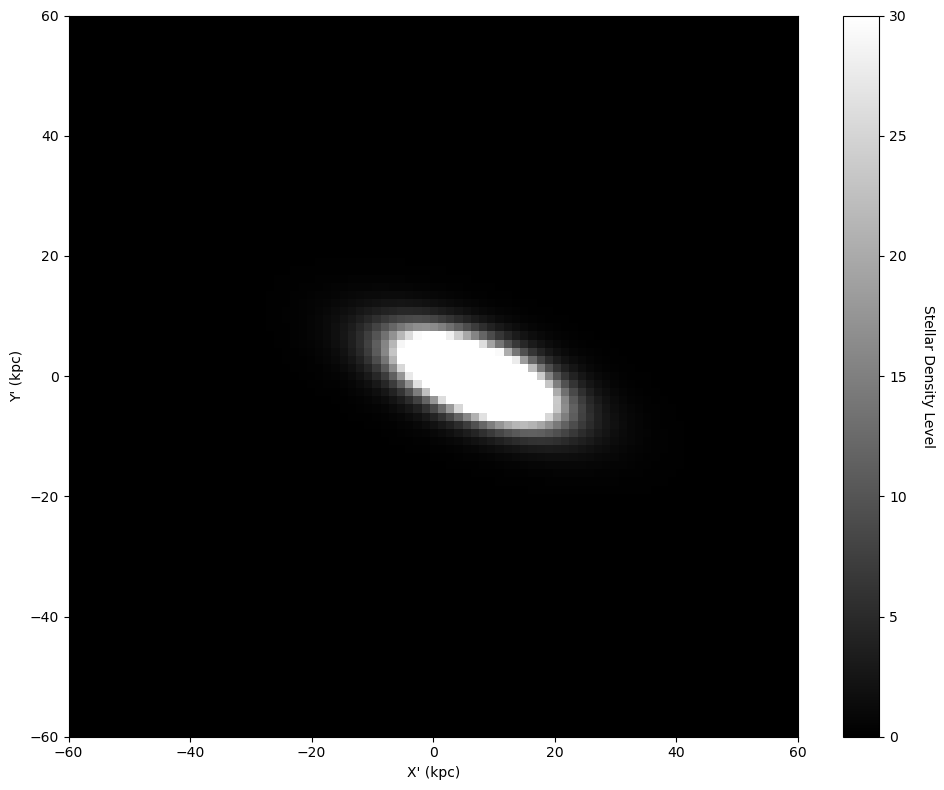

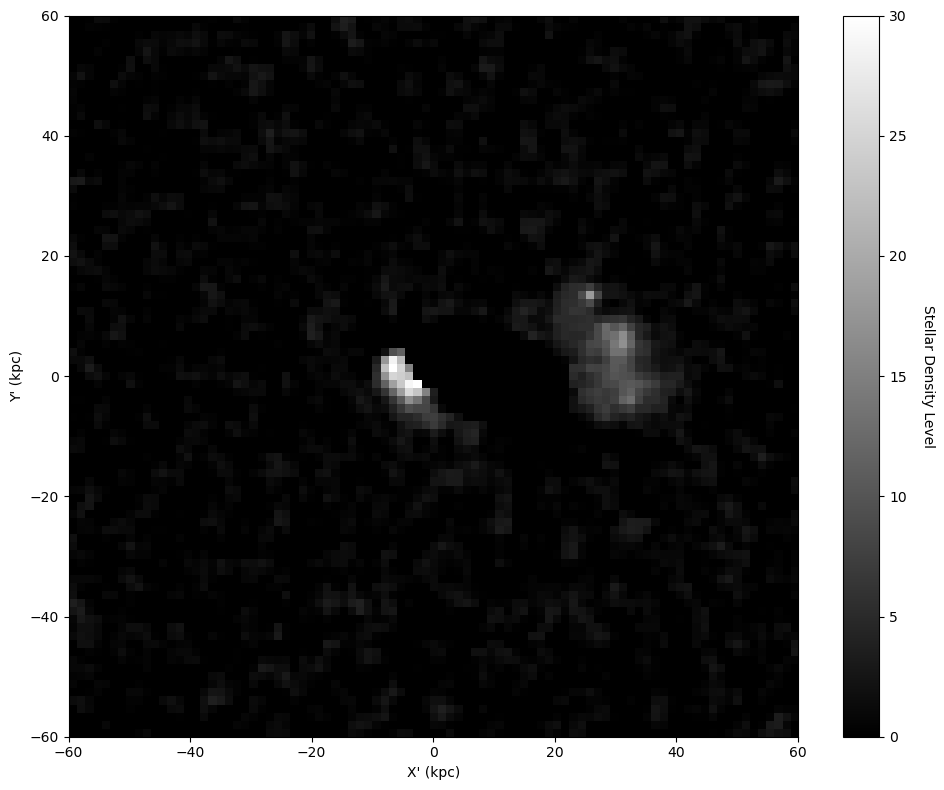

File name: mf_storm_2_d=72.3_a=319.9_pix=8000.fits
Fitted Parameters:
A  = 999.1127
h = 1.8139
q = 1.7694
x_offset = 5.1907
y_offset = 0.2579
theta = -3261163.4094
C  = 0.0790


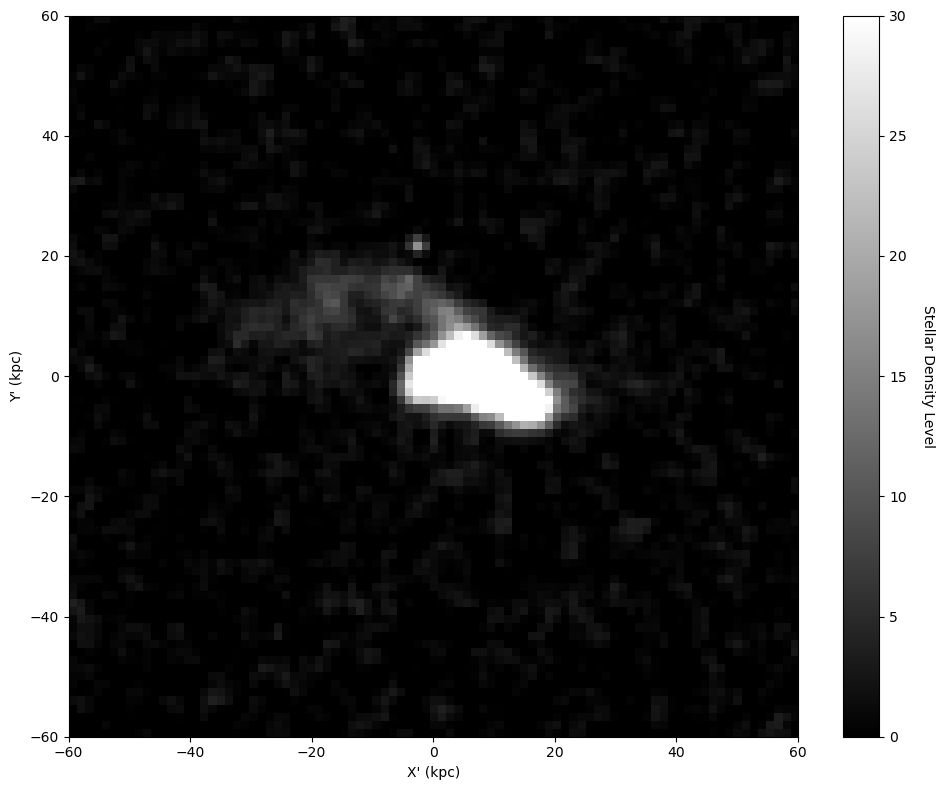

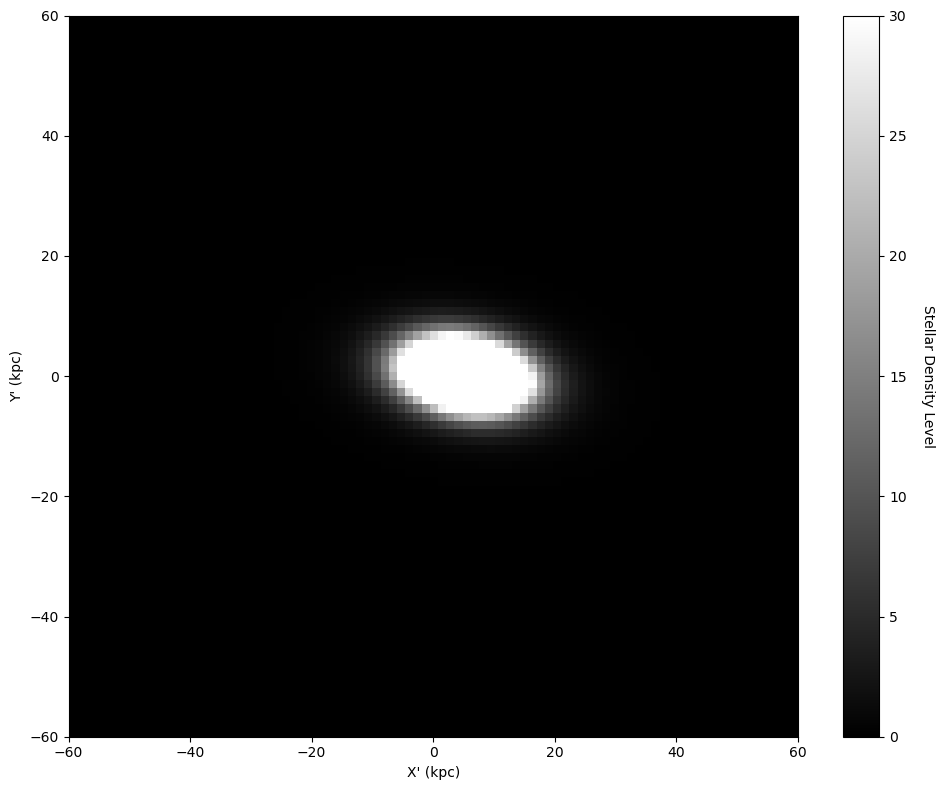

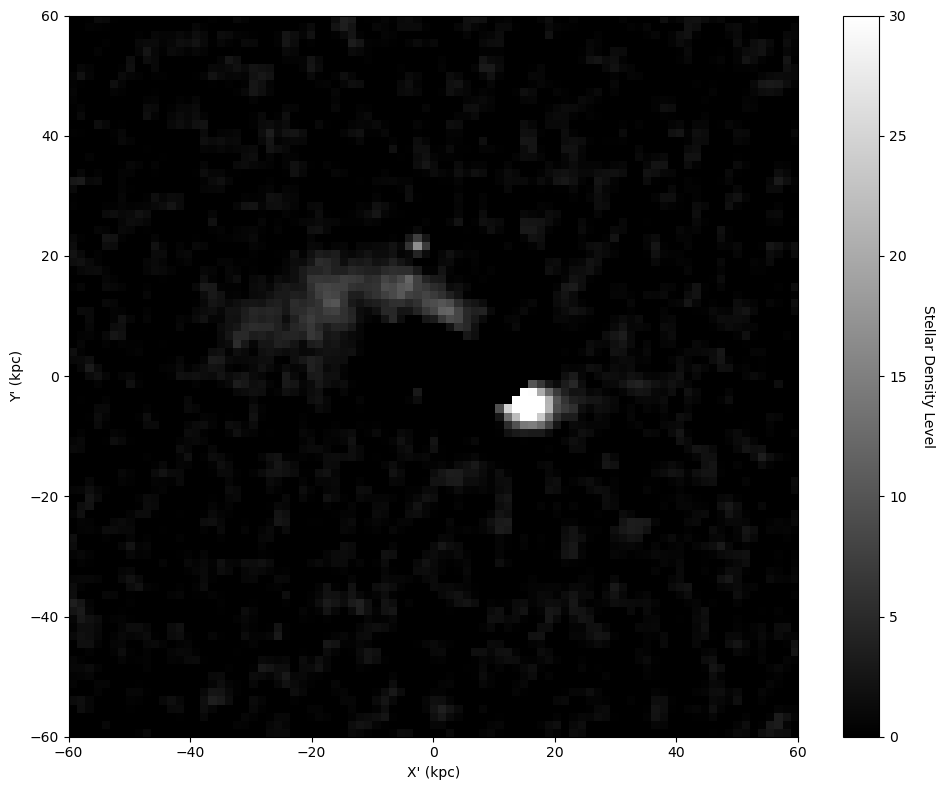

File name: mf_storm_2_d=74.9_a=182.4_pix=8000.fits
Fitted Parameters:
A  = 966.1190
h = 3.5447
q = -0.5253
x_offset = 5.0290
y_offset = 0.2820
theta = -16008136.1492
C  = -0.1029


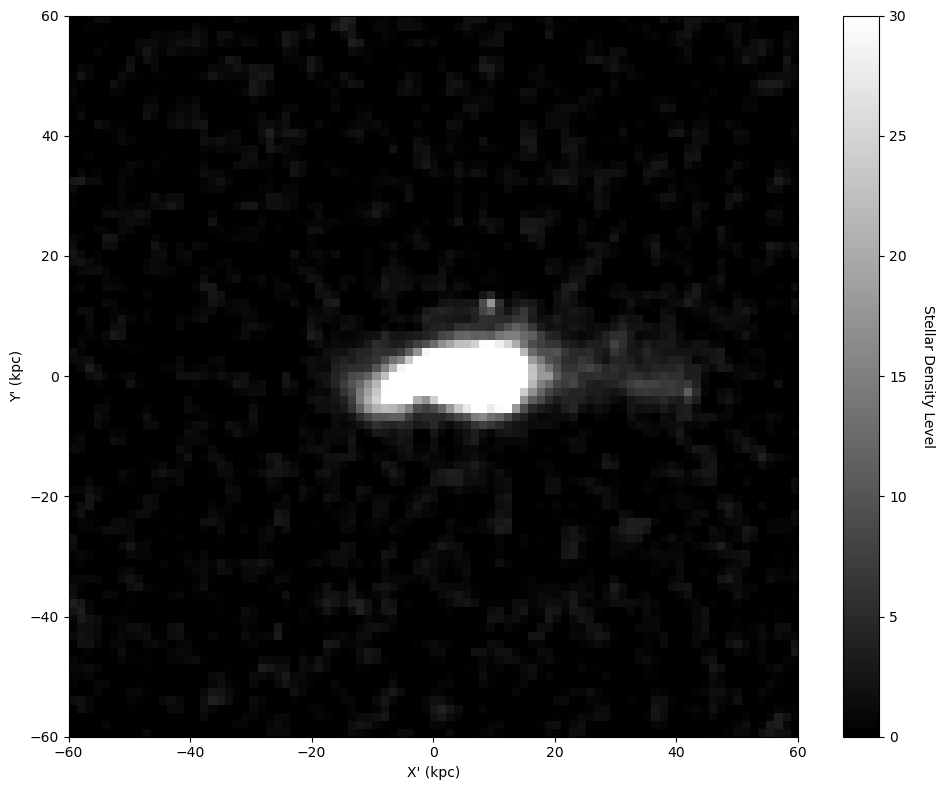

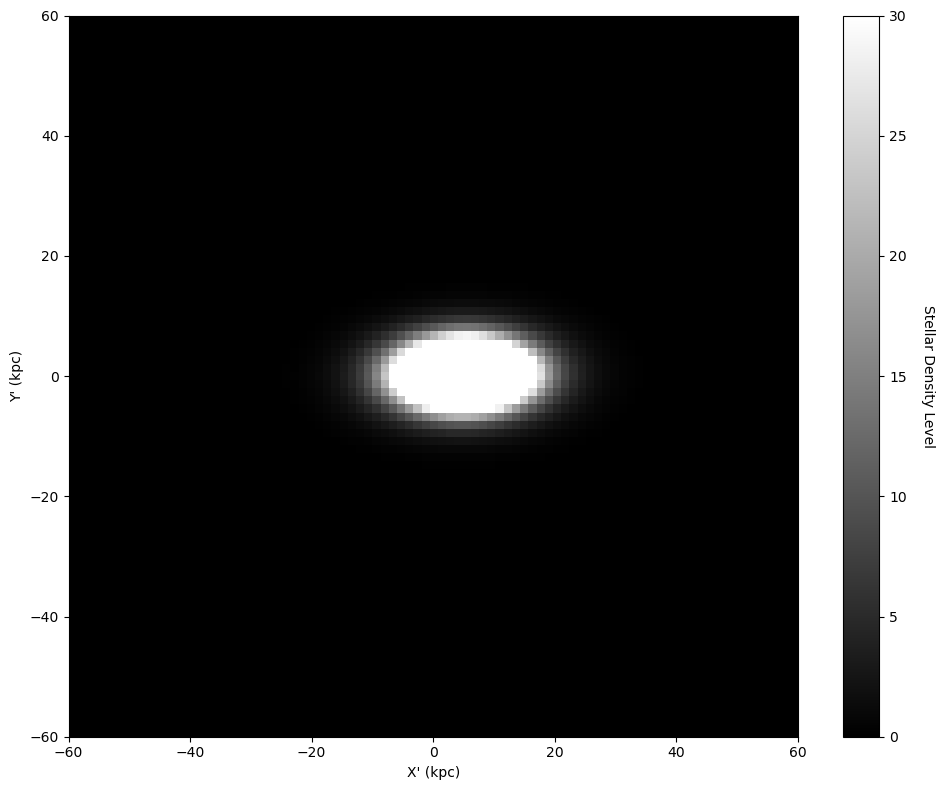

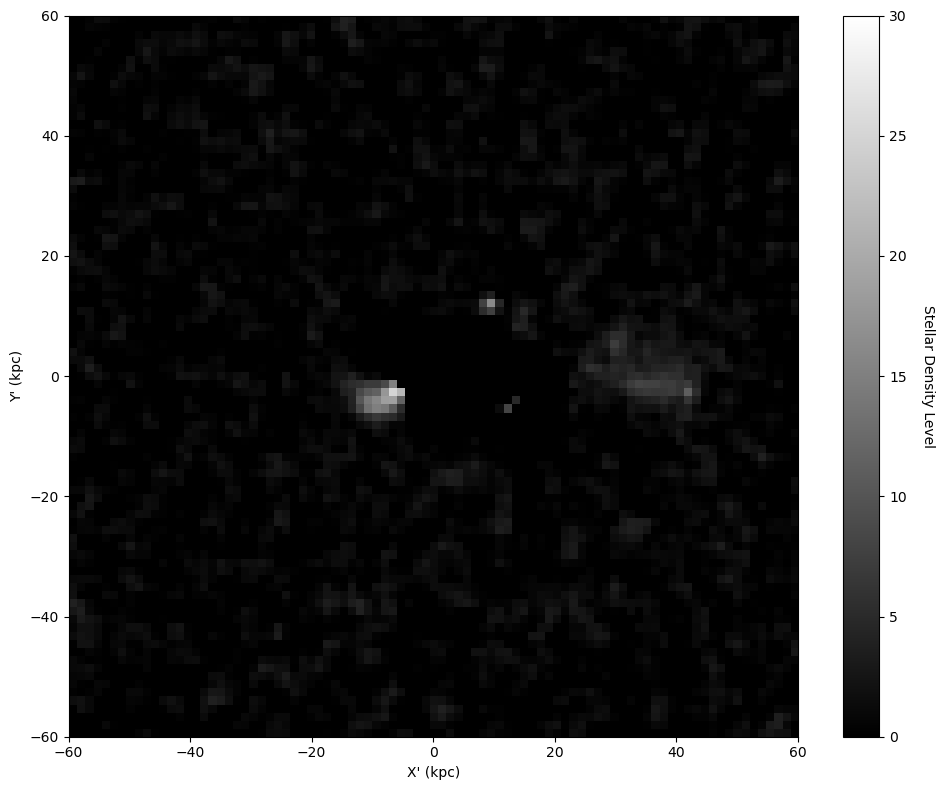

File name: mf_storm_2_d=77.4_a=44.9_pix=8000.fits
Fitted Parameters:
A  = 955.7771
h = 3.9988
q = -0.4167
x_offset = 5.8331
y_offset = -0.1484
theta = -20360294.3752
C  = -0.0660


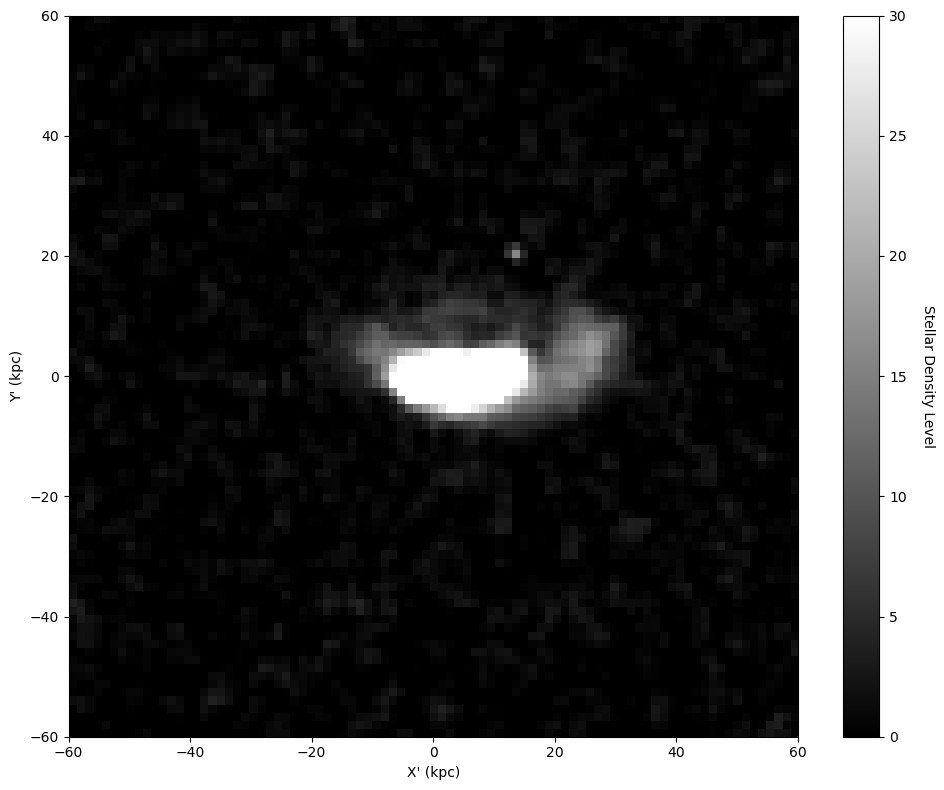

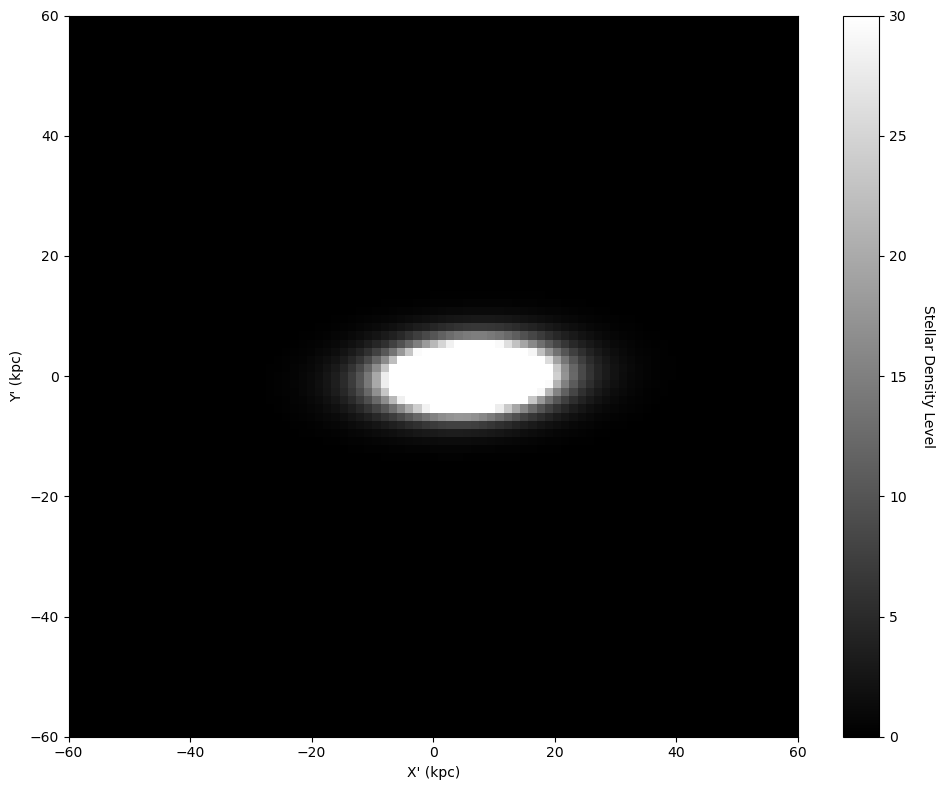

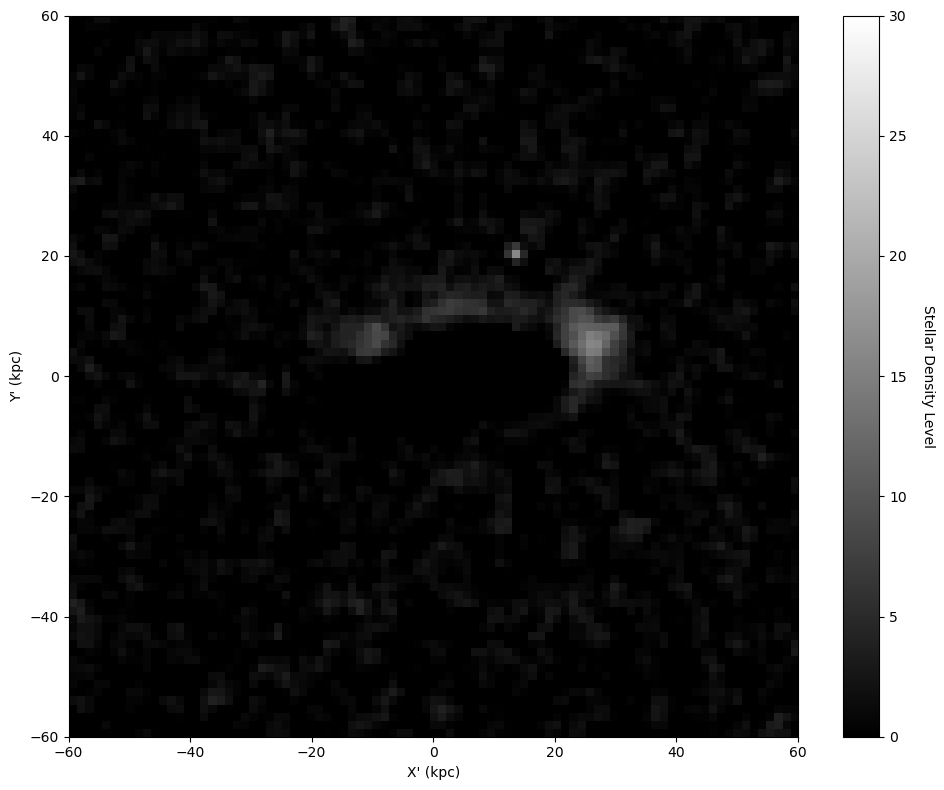

File name: mf_storm_2_d=80.0_a=267.4_pix=8000.fits
Fitted Parameters:
A  = 884.5851
h = 4.4150
q = 0.3841
x_offset = 6.1466
y_offset = 0.0977
theta = -6600388.8953
C  = -0.1563


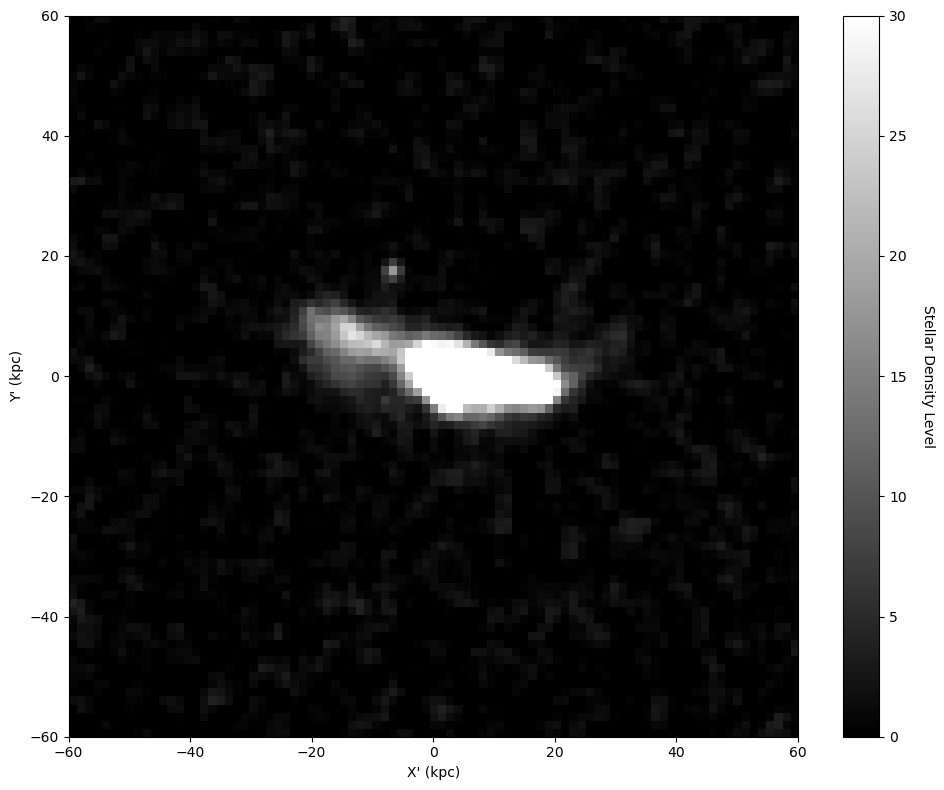

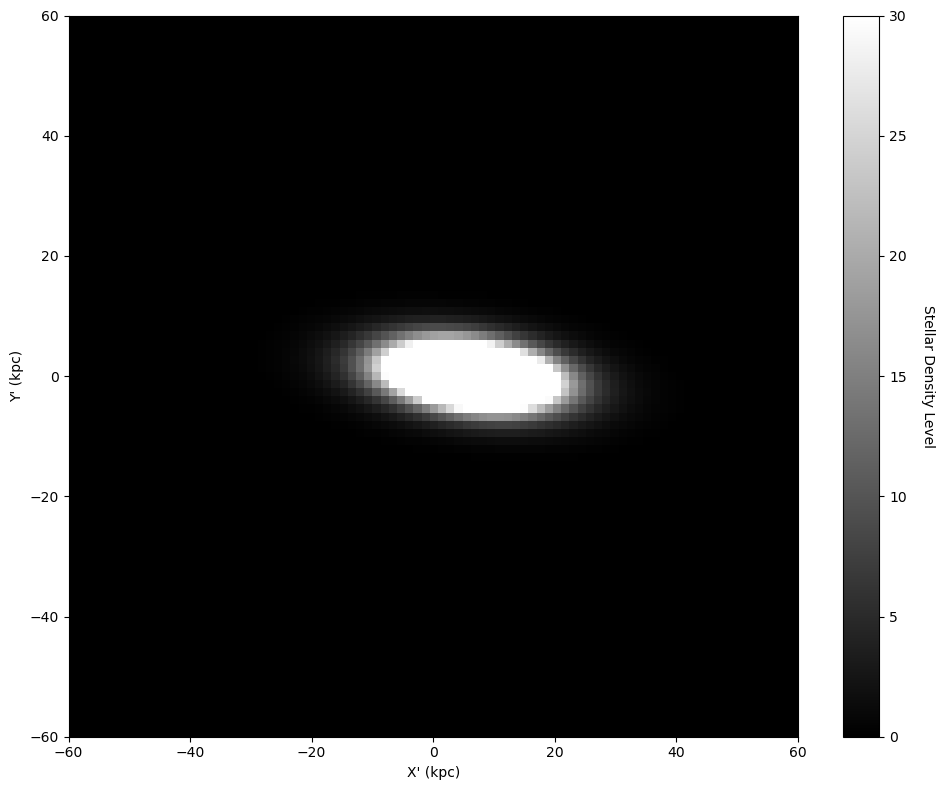

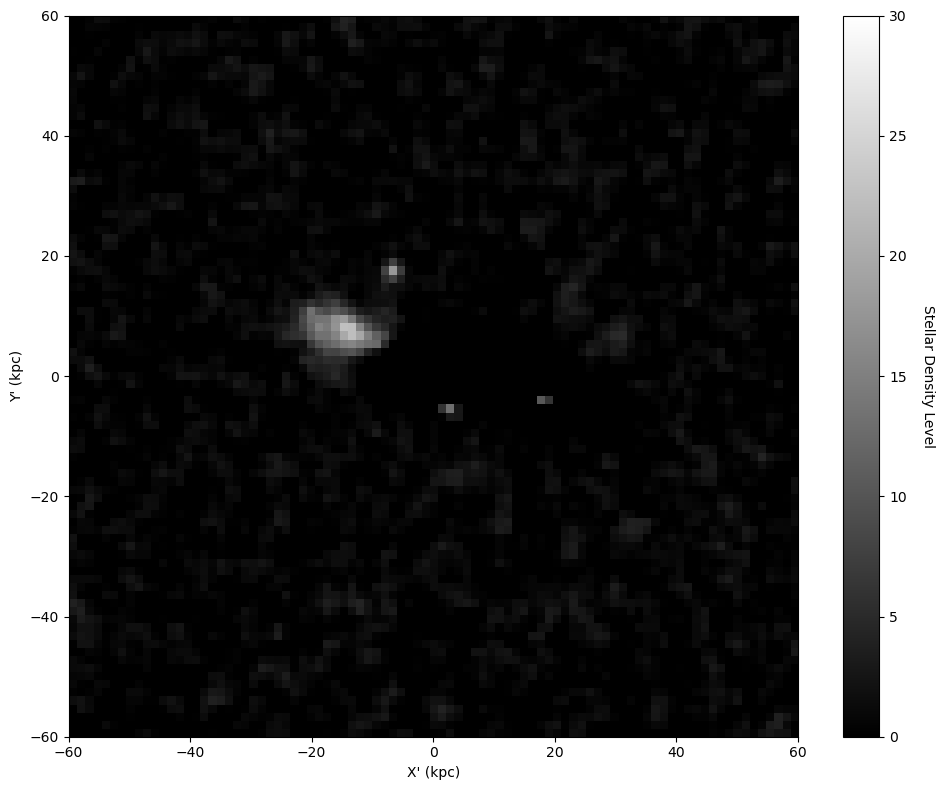

File name: mf_storm_2_d=82.5_a=129.8_pix=8000.fits
Fitted Parameters:
A  = 1162.9964
h = 3.4150
q = 0.4494
x_offset = 5.8017
y_offset = 0.2472
theta = -7480138.6952
C  = 0.0260


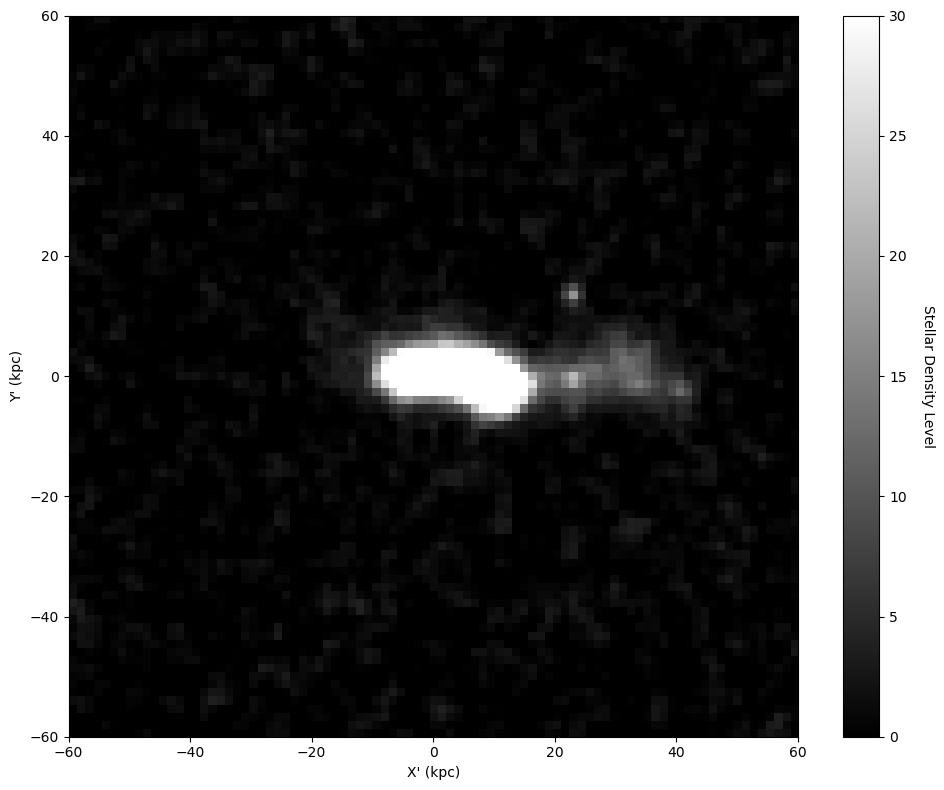

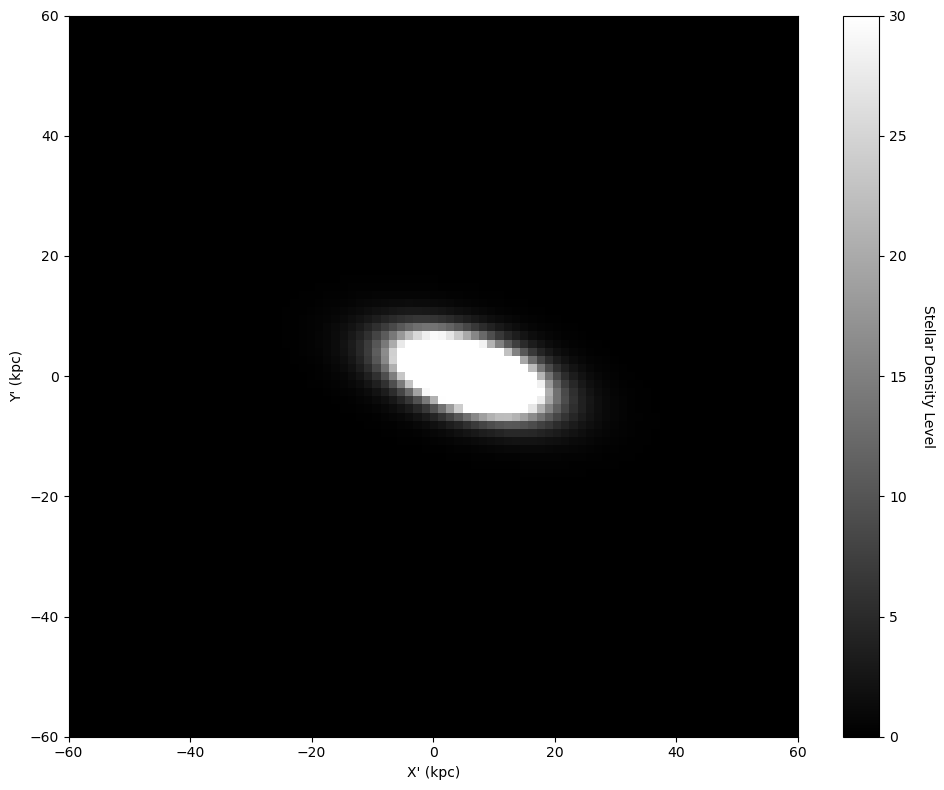

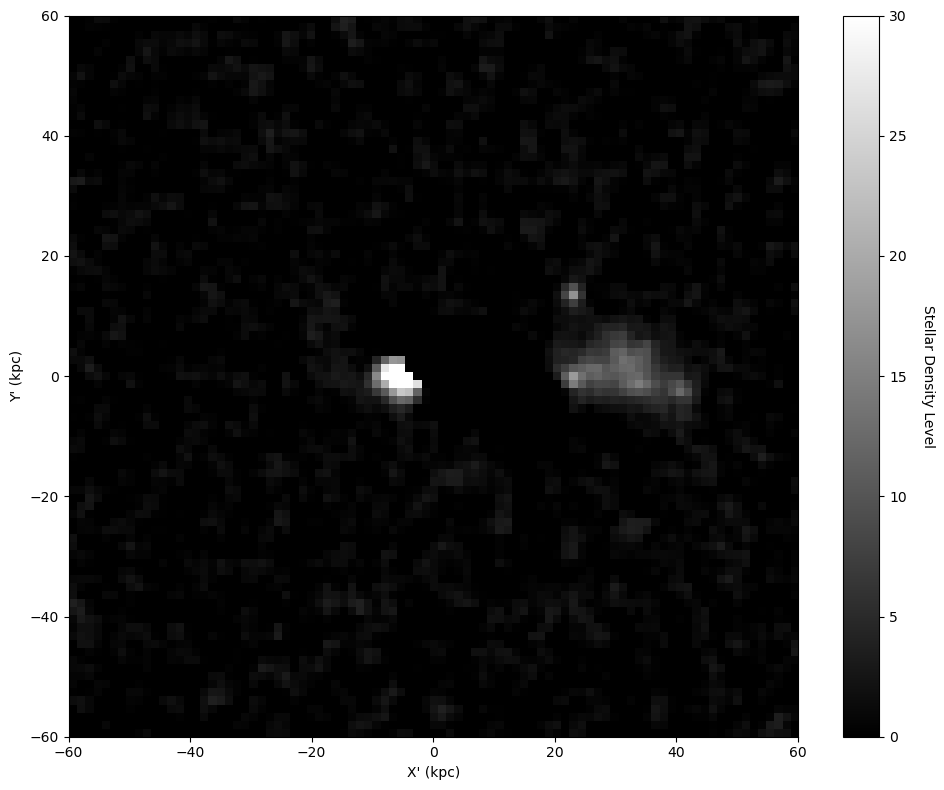

File name: mf_storm_2_d=85.0_a=352.3_pix=8000.fits
Fitted Parameters:
A  = 1175.5149
h = 3.3204
q = -0.4719
x_offset = 4.9178
y_offset = 0.0178
theta = -17026643.6286
C  = -0.0185


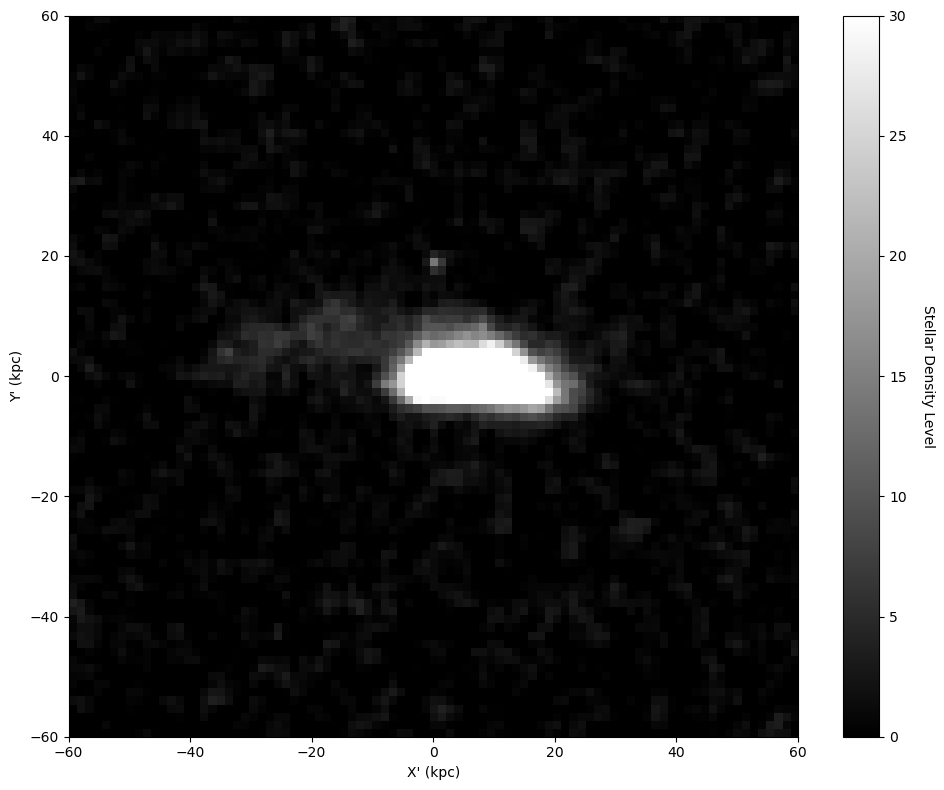

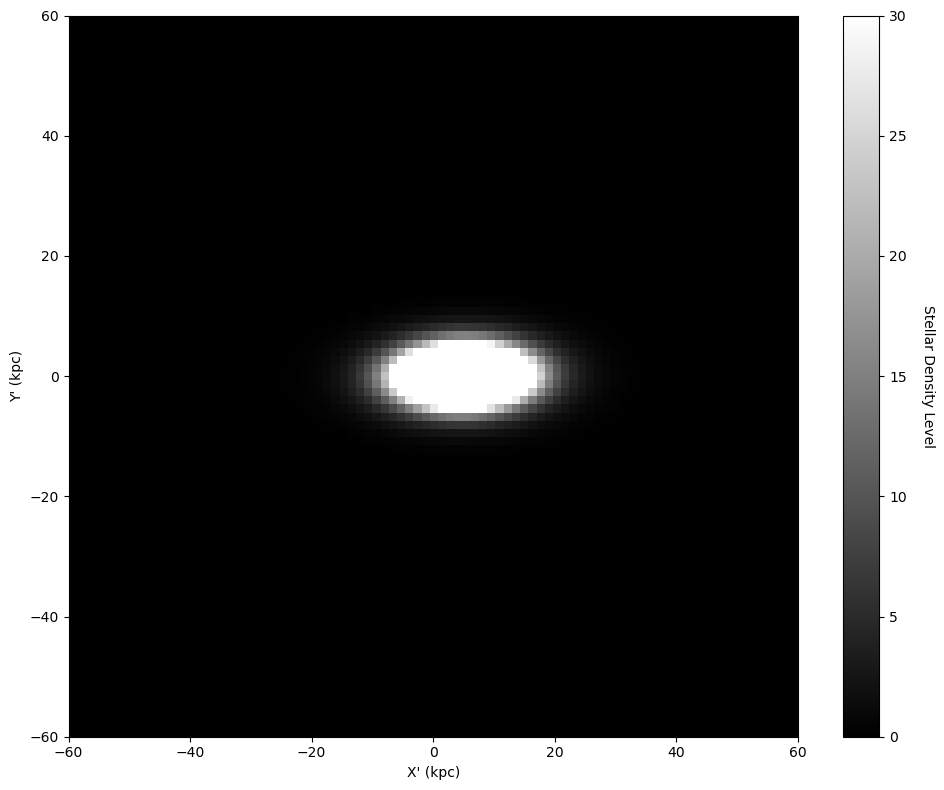

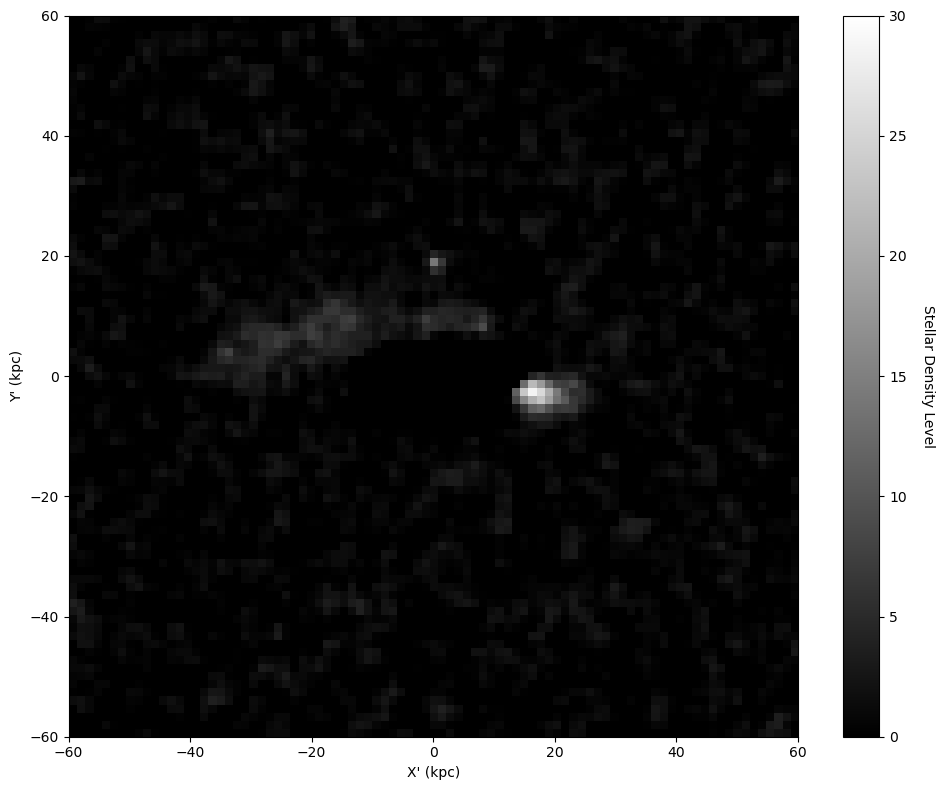

File name: mf_storm_2_d=87.5_a=214.8_pix=8000.fits
Fitted Parameters:
A  = 1035.5348
h = 4.0129
q = 0.3933
x_offset = 5.7902
y_offset = -0.1977
theta = -9465442.8659
C  = -0.1368


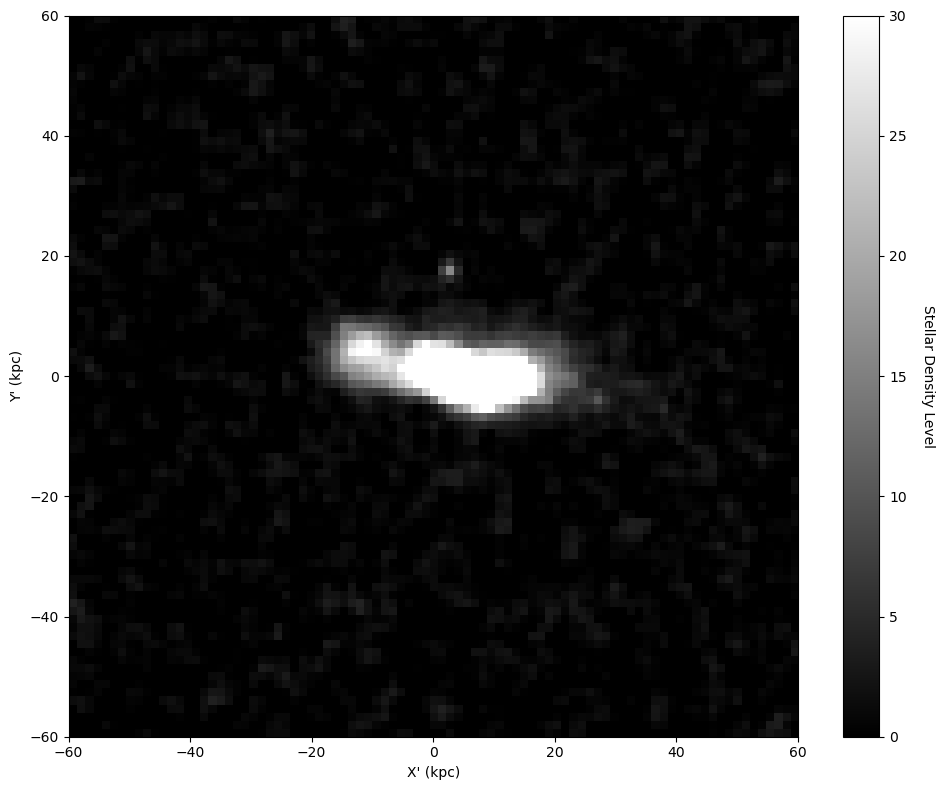

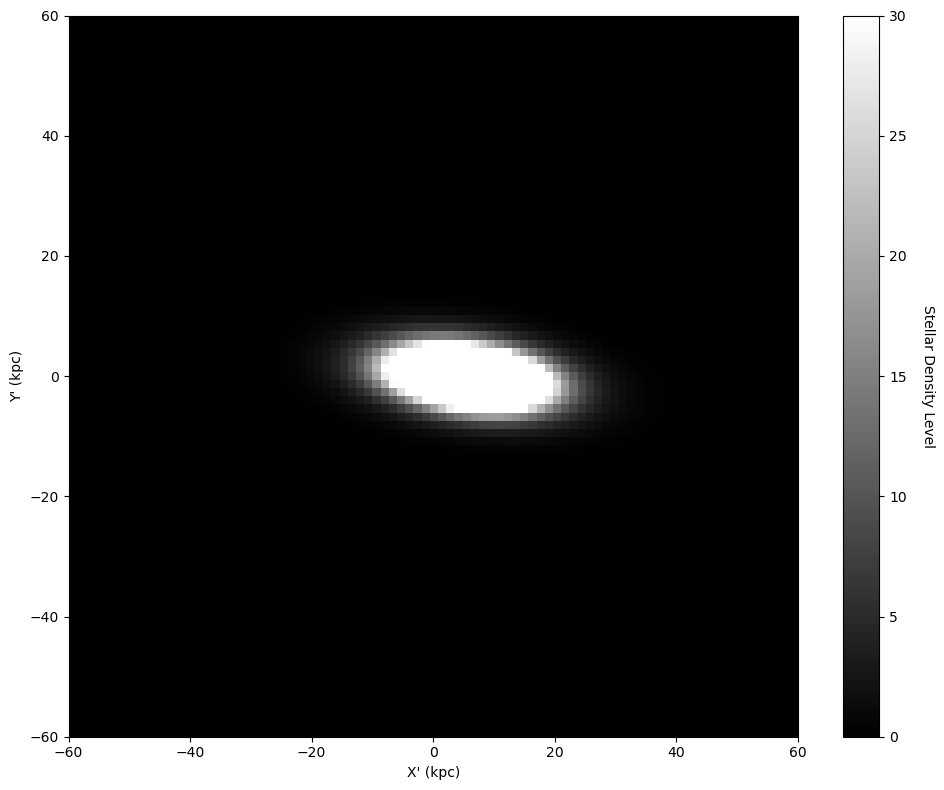

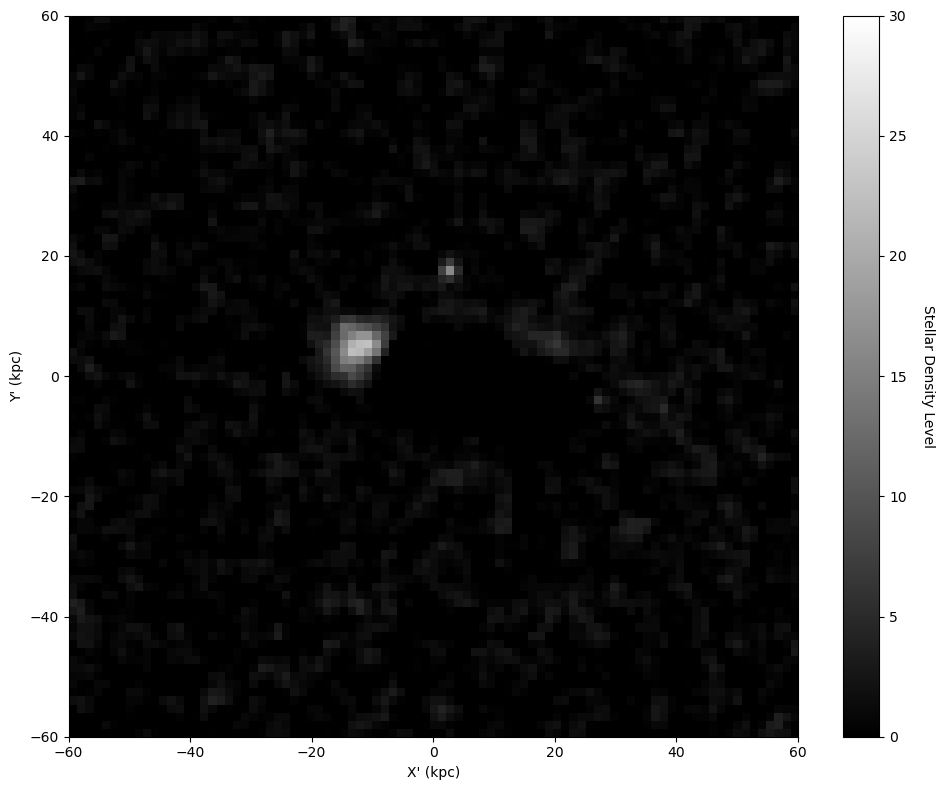

File name: mf_storm_2_d=90.0_a=77.3_pix=8000.fits
Fitted Parameters:
A  = 935.1593
h = 4.4722
q = -0.3566
x_offset = 5.8440
y_offset = 0.0227
theta = -14241295.1494
C  = -0.1875


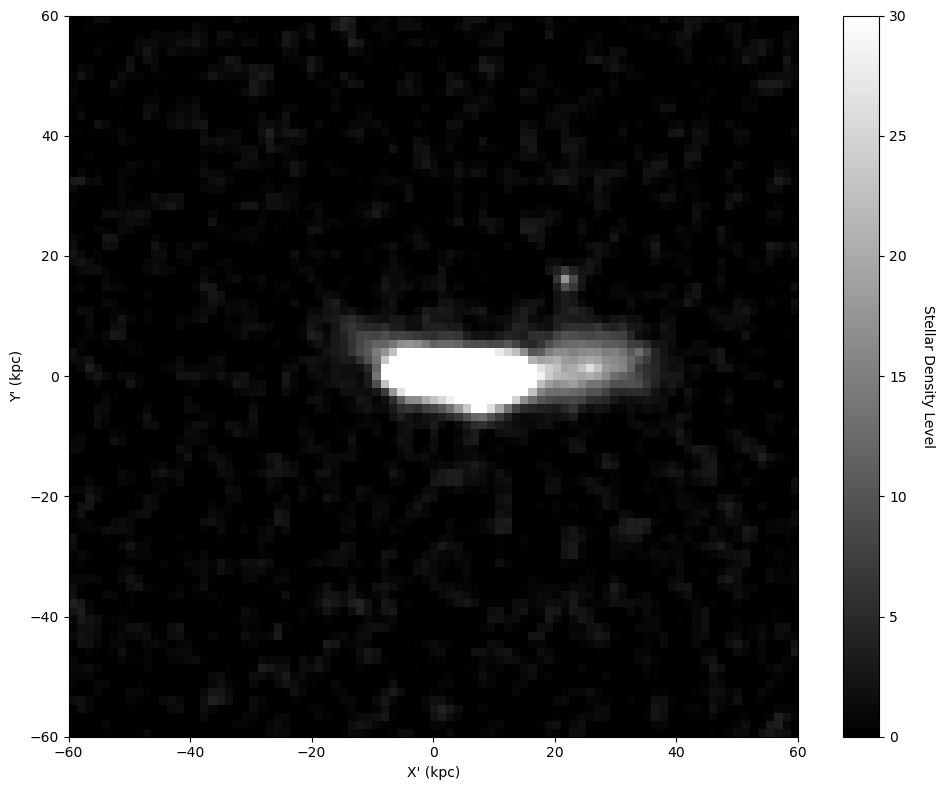

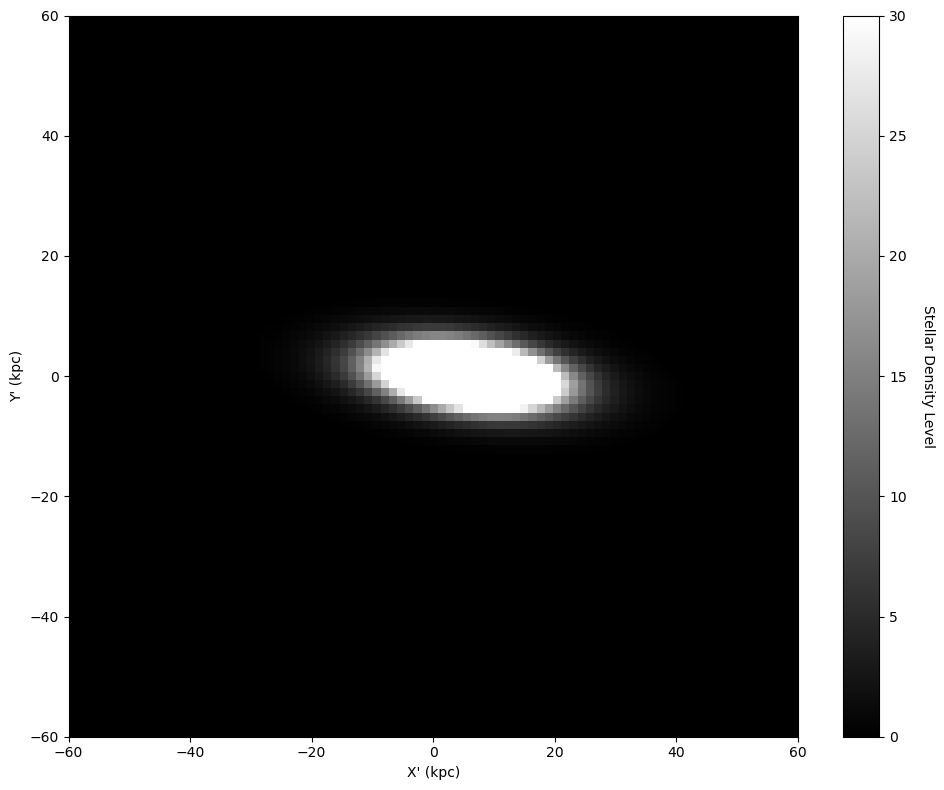

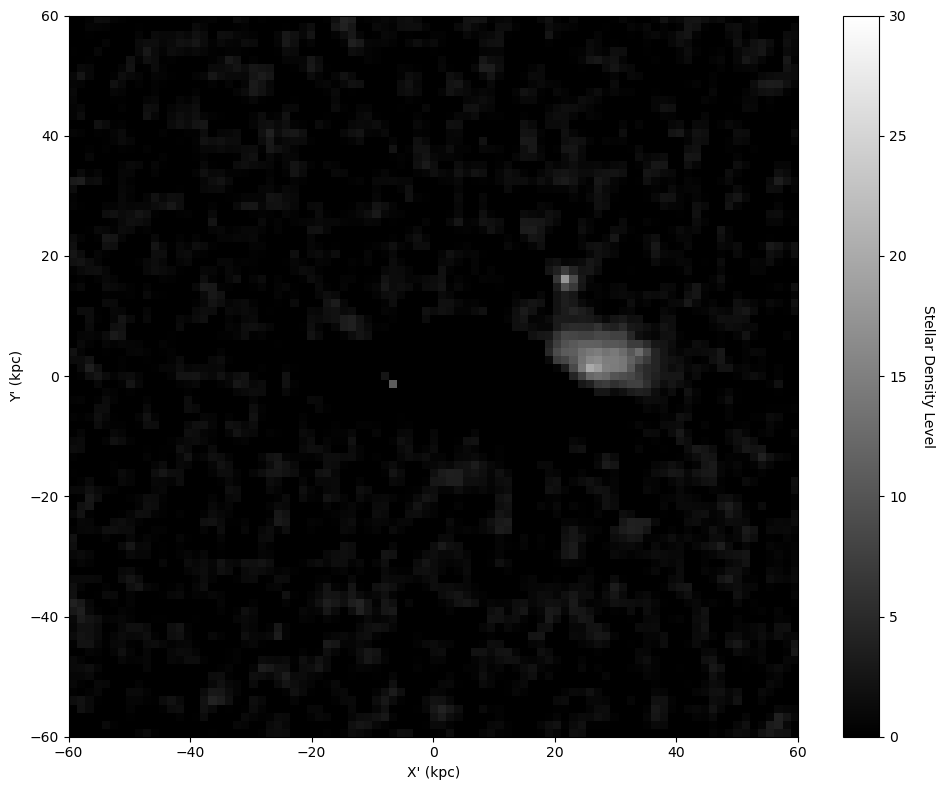

In [7]:
# apply the 2D exponential fit algorithm

if os.path.exists(centers_path):
    os.remove(centers_path)

for file in sorted(mf_catalogs_path.iterdir()):
    if file.is_file():

        print(f'File name: {file.name}')

        numbers = [float(num) for num in re.findall(r'\d+(?:\.\d+)*', f'{file.name}')]
        angles = numbers[1:-1]
        d = angles[0]
        a = angles[1]
        
        hdul = fits.open(f'{mf_catalogs_path}/{file.name}')
        data=hdul[0].data

        # generate synthetic mock data with noise
        x_line = np.linspace(-60, 60, 89)
        y_line = np.linspace(-60, 60, 89)
        X, Y = np.meshgrid(x_line, y_line)
        
        # Flatten the arrays to 1-D for curve_fit
        x_flat = X.ravel()
        y_flat = Y.ravel()
        z_flat = data.ravel()
        
        # combine independent variables into an (2, N) shaped array
        independent_vars = np.vstack((x_flat, y_flat))
        
        # perform the optimization
        fitted_params, covariance = curve_fit(
            f=exponential_2d, 
            xdata=independent_vars, 
            ydata=z_flat, 
            p0=initial_guess
        )

        Z_fitted = exponential_2d((X, Y), *fitted_params)

        z_fit_max = np.max(Z_fitted)
        mask_thresh = mask_cutoff * z_fit_max # Change thresh to what you want
        mask = Z_fitted < mask_thresh
        residual = data - Z_fitted
        masked_residual = residual.copy()
        masked_residual[~mask] = 0

        # Extract and view results
        A_fit, h_fit, q_fit, x_offset_fit, y_offset_fit, theta_fit, C_fit = fitted_params
        print("Fitted Parameters:")
        print(f"A  = {A_fit:.4f}")
        print(f"h = {h_fit:.4f}")
        print(f"q = {q_fit:.4f}")
        print(f"x_offset = {x_offset_fit:.4f}")
        print(f"y_offset = {y_offset_fit:.4f}")
        print(f"theta = {theta_fit:.4f}")
        print(f"C  = {C_fit:.4f}")

        with open(f'{centers_path}', 'a') as file:
            file.write('center of ' f'{galaxy_name}' ' at d=' f'{d}' ' and a=' f'{a}' ':' f'{x_offset_fit:.4f}' ',' f'{y_offset_fit:.4f}' '\n')

        plot(data, f'original', d, a, save=True)
        plot(Z_fitted, f'model', d, a, save=True)
        plot(masked_residual, f'reduced', d, a, save=True, save_fits=True)